In [56]:
# Cell 1: Load data, GA results, and run RF tuning for
#         Baseline + GA top-5 USING THE OLD TUNING FUNCTION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display

from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import recall_score
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
import shap
# ------------------------------------
# 1) Load train / test data
# ------------------------------------

X_train = pd.read_csv("../nz/Xtr_nz.csv")
X_test  = pd.read_csv("../nz/Xte_nz.csv")

y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

y_np = y_train.to_numpy().ravel()
y_te = y_test.to_numpy().ravel()

# ------------------------------------
# 2) Load GA results (ga_best.npz)
# ------------------------------------
ga_npz = np.load("../data/ga_svm_13penalty.npz", allow_pickle=True)
print("\n[INFO] npz keys:", ga_npz.files)

top_scores = np.asarray(ga_npz["top_scores"], dtype=float)

# Build top_cols_all from npz (handle both 'top_masks' and 'top_cols')
if "top_masks" in ga_npz.files:
    raw_masks = list(ga_npz["top_masks"])  # list of boolean arrays
    top_cols_all = [
        np.flatnonzero(np.asarray(m, dtype=bool)).astype(int)
        for m in raw_masks
    ]
else:
    raw_cols = list(ga_npz["top_cols"])    # list of index arrays
    top_cols_all = [np.asarray(c, dtype=int) for c in raw_cols]

n_feat_total = X_train.shape[1]
print(f"[INFO] Loaded {len(top_cols_all)} GA feature sets.")

# ------------------------------------
# 3) Define PARAM_DIST and old tuning settings
#    (EXACTLY as in your previous test code)
# ------------------------------------
PARAM_DIST = {
    "n_estimators": randint(100, 650),
    "max_depth": [None, 8, 12],
    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 8),
    "bootstrap": [True],
    "max_samples": [None, 0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
    "criterion": ["gini", "entropy"],
}

STAGE1_N_ITER = globals().get("STAGE1_N_ITER", 80)  # keep 80 if defined, same as before
RANDOM_STATE  = 42

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=2042)

def tune_rf_for_features(feature_idx, label):
    """
    RF hyperparameter tuning on a given feature subset using the EXACT same
    RandomizedSearchCV settings as before (so results are comparable).
    """
    X_sub = X_train.iloc[:, feature_idx].to_numpy()

    rs = RandomizedSearchCV(
        estimator=RandomForestClassifier(random_state=2042, n_jobs=-1),
        param_distributions=PARAM_DIST,
        n_iter=STAGE1_N_ITER,
        scoring="roc_auc",
        cv=cv5,
        n_jobs=-1,
        random_state=2042,
        verbose=0
    )
    rs.fit(X_sub, y_np)

    best_params = dict(rs.best_params_)
    # Clean up for direct RF instantiation
    best_params.pop("random_state", None)
    best_params.pop("n_jobs", None)
    if best_params.get("bootstrap") is False:
        best_params.pop("max_samples", None)

    print(f"[CV] {label} best AUC = {rs.best_score_:.4f}")
    print(f"[CV] {label} best params = {best_params}")
    return best_params, float(rs.best_score_)

# ------------------------------------
# 4) Build feature_sets: Baseline + GA top-5 (by GA score)
# ------------------------------------
N_TOP_GA = 5

# sort GA solutions by GA score (descending)
sorted_idx = np.argsort(top_scores)[::-1]
top_idx    = sorted_idx[:N_TOP_GA]

feature_sets = []

# (0) Baseline: all 84 features
all_cols = np.arange(n_feat_total, dtype=int)
feature_sets.append({
    "name": "Baseline (ALL wrapper)",
    "cols": all_cols,
})

# (1) GA top-5 feature subsets
for rank, idx in enumerate(top_idx, 1):
    cols = np.asarray(top_cols_all[idx], dtype=int)
    feature_sets.append({
        "name": f"GA-{rank} (idx={idx})",
        "cols": cols,
        "ga_score": float(top_scores[idx]),
    })

print("\n[INFO] Feature sets to tune (Baseline + GA top-5):")
for fs in feature_sets:
    print(f"  {fs['name']}: d={len(fs['cols'])}")

# ------------------------------------
# 5) Run tuning for each feature set USING THE SAME FUNCTION
# ------------------------------------
for fs in feature_sets:
    params, cv_auc = tune_rf_for_features(fs["cols"], fs["name"])
    fs["best_params"] = params
    fs["cv_auc"]      = cv_auc


X_train: (82, 32)
X_test : (36, 32)
y_train: (82,)
y_test : (36,)

[INFO] npz keys: ['run_ids', 'top_scores', 'top_masks', 'top_cols']
[INFO] Loaded 5 GA feature sets.

[INFO] Feature sets to tune (Baseline + GA top-5):
  Baseline (ALL wrapper): d=32
  GA-1 (idx=0): d=14
  GA-2 (idx=1): d=13
  GA-3 (idx=2): d=13
  GA-4 (idx=3): d=13
  GA-5 (idx=4): d=13
[CV] Baseline (ALL wrapper) best AUC = 0.8733
[CV] Baseline (ALL wrapper) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.3, 'max_samples': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 135}
[CV] GA-1 (idx=0) best AUC = 0.8239
[CV] GA-1 (idx=0) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.5, 'max_samples': 0.6, 'min_samples_leaf': 2, 'min_samples_split': 17, 'n_estimators': 364}
[CV] GA-2 (idx=1) best AUC = 0.8430
[CV] GA-2 (idx=1) best params = {'bootstrap': True, 'class_weight': 

[Train CV ROC] Baseline (ALL wrapper): AUC 0.8733 ± 0.0884
[Train CV ROC] GA-1 (idx=0): AUC 0.8239 ± 0.0802
[Train CV ROC] GA-2 (idx=1): AUC 0.8430 ± 0.1048
[Train CV ROC] GA-3 (idx=2): AUC 0.8436 ± 0.1298
[Train CV ROC] GA-4 (idx=3): AUC 0.8533 ± 0.0786
[Train CV ROC] GA-5 (idx=4): AUC 0.8709 ± 0.0728


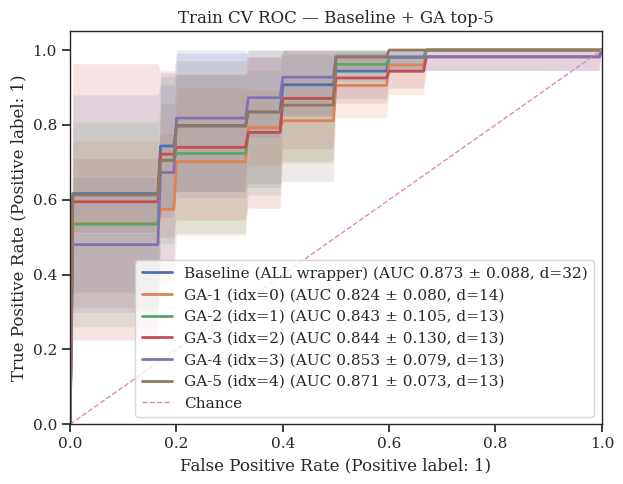

In [57]:
# Cell 2: Train CV ROC for Baseline + GA top-5
#         (NO NEW TUNING; use fs["best_params"] from Cell 1)

FPR_GRID = np.linspace(0.0, 1.0, 201)

def cv_roc_with_fixed_params(X, y, params, label, cv):
    """
    Given fixed RF params, compute mean ± std ROC curves over the given CV object.
    """
    tprs = []
    aucs = []

    for tr_idx, va_idx in cv.split(X, y):
        clf = RandomForestClassifier(
            random_state=2042,
            n_jobs=-1,
            **params
        )
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        fpr, tpr, _ = roc_curve(y[va_idx], prob)
        auc_fold = roc_auc_score(y[va_idx], prob)
        aucs.append(auc_fold)

        tpr_i = np.interp(FPR_GRID, fpr, tpr, left=0.0, right=1.0)
        tpr_i[0]  = 0.0
        tpr_i[-1] = 1.0
        tprs.append(tpr_i)

    tprs     = np.vstack(tprs)
    mean_tpr = tprs.mean(axis=0)
    std_tpr  = tprs.std(axis=0)
    auc_mean = float(np.mean(aucs))
    auc_std  = float(np.std(aucs))

    print(f"[Train CV ROC] {label}: AUC {auc_mean:.4f} ± {auc_std:.4f}")
    return mean_tpr, std_tpr, auc_mean, auc_std

plt.figure(figsize=(6.4, 5.0))

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    X_sub = X_train.iloc[:, cols].to_numpy()

    mean_tpr, std_tpr, auc_mean, auc_std = cv_roc_with_fixed_params(
        X_sub, y_np, params, fs["name"], cv5
    )

    fs["cv_auc_mean"] = auc_mean
    fs["cv_auc_std"]  = auc_std

    label = f"{fs['name']} (AUC {auc_mean:.3f} ± {auc_std:.3f}, d={len(cols)})"
    plt.plot(FPR_GRID, mean_tpr, lw=2, label=label)
    plt.fill_between(
        FPR_GRID,
        np.maximum(mean_tpr - std_tpr, 0.0),
        np.minimum(mean_tpr + std_tpr, 1.0),
        alpha=0.15,
    )

plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance")
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("Train CV ROC — Baseline + GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [58]:
# ------------------------------------------------
# 1) Collect only GA-based feature sets (exclude Baseline)
# ------------------------------------------------
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]

if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found. Make sure feature_sets contains entries named 'GA-1', 'GA-2', ...")

# Each GA subset already has:
#   - fs["cv_auc_mean"]: mean AUC over CV folds (from Cell 2)
#   - fs["cv_auc_std"] : std  AUC over CV folds (from Cell 2)
# We now summarize:
#   (1) per-subset CV AUC statistics in a table
#   (2) across-subset AUC stability: how much these per-subset means vary
#       -> treat each GA run's cv_auc_mean as one observation
#          and compute mean / std across runs.

subset_names = [fs["name"] for fs in ga_feature_sets]
subset_sizes = [len(fs["cols"]) for fs in ga_feature_sets]
ga_auc_means = np.array([fs["cv_auc_mean"] for fs in ga_feature_sets], dtype=float)
ga_auc_stds  = np.array([fs["cv_auc_std"]  for fs in ga_feature_sets], dtype=float)

# --------------------------------------------
# Table 1: per-GA-subset CV AUC summary
# --------------------------------------------
auc_table = pd.DataFrame({
    "subset": subset_names,
    "n_features": subset_sizes,
    "cv_auc_mean_over_folds": ga_auc_means,
    "cv_auc_std_over_folds": ga_auc_stds,
})
auc_table = auc_table.sort_values("subset").reset_index(drop=True)

# Across-subset AUC stability:
#   - ga_auc_means: length = n_GA_runs (e.g., 5)
#   - mean: average AUC across GA runs
#   - std : how much the *average* AUC changes between GA runs
auc_across_mean = float(ga_auc_means.mean())
auc_across_std  = float(ga_auc_means.std(ddof=1))  # sample std across GA subsets

auc_stability_summary = pd.DataFrame({
    "metric": ["across_subsets_mean_AUC", "across_subsets_std_AUC"],
    "value":  [auc_across_mean,            auc_across_std]
})

# --------------------------------------------
# 2) Jaccard similarity between GA subsets
# --------------------------------------------
def jaccard_similarity(indices_a, indices_b):
    """
    Compute Jaccard similarity between two index sets:
      J(A,B) = |A ∩ B| / |A ∪ B|
    """
    set_a = set(indices_a)
    set_b = set(indices_b)
    union = set_a | set_b
    if not union:
        return 0.0
    inter = set_a & set_b
    return len(inter) / len(union)

n_ga   = len(ga_feature_sets)
labels = [fs["name"] for fs in ga_feature_sets]

jacc_matrix = np.zeros((n_ga, n_ga), dtype=float)

# Full Jaccard matrix (symmetric, diagonal = 1)
for i in range(n_ga):
    for j in range(n_ga):
        jacc_matrix[i, j] = jaccard_similarity(
            ga_feature_sets[i]["cols"],
            ga_feature_sets[j]["cols"]
        )

# DataFrame for a clean matrix view
jacc_df = pd.DataFrame(jacc_matrix, index=labels, columns=labels)

# Upper-triangular values (i < j) for summary mean ± std
upper_vals = [
    jacc_matrix[i, j]
    for i in range(n_ga)
    for j in range(i + 1, n_ga)
]

jacc_mean = float(np.mean(upper_vals)) if upper_vals else 0.0
jacc_std  = float(np.std(upper_vals, ddof=1)) if len(upper_vals) > 1 else 0.0

jacc_summary = pd.DataFrame({
    "metric": ["mean_Jaccard_over_pairs", "std_Jaccard_over_pairs"],
    "value":  [jacc_mean,                  jacc_std]
})


# --------------------------------------------
# 3) Sensitivity comparison: mean recall at 0.5
# --------------------------------------------
def cv_sensitivity_at_threshold(X, y, params, cv, threshold=0.5):
    """
    Compute mean ± std sensitivity (recall for positive class)
    across CV folds, at a fixed probability threshold.
    """
    recalls = []

    for tr_idx, va_idx in cv.split(X, y):
        clf = RandomForestClassifier(
            random_state=2042,
            n_jobs=-1,
            **params
        )
        clf.fit(X[tr_idx], y[tr_idx])
        prob = clf.predict_proba(X[va_idx])[:, 1]

        y_pred = (prob >= threshold).astype(int)
        rec = recall_score(y[va_idx], y_pred, pos_label=1)
        recalls.append(rec)

    recalls = np.array(recalls, dtype=float)
    return float(recalls.mean()), float(recalls.std(ddof=1))

sens_rows = []
for fs in ga_feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])
    X_sub  = X_train.iloc[:, cols].to_numpy()
    y_sub  = y_np  # same labels as before

    sens_mean, sens_std = cv_sensitivity_at_threshold(
        X_sub, y_sub, params, cv5, threshold=0.5
    )

    sens_rows.append({
        "subset": fs["name"],
        "n_features": len(cols),
        "cv_auc_mean_over_folds": fs["cv_auc_mean"],
        "cv_auc_std_over_folds":  fs["cv_auc_std"],
        "sensitivity_mean_at_0.5": sens_mean,
        "sensitivity_std_at_0.5":  sens_std,
    })

sens_table = pd.DataFrame(sens_rows).sort_values("subset").reset_index(drop=True)


# --------------------------------------------
# 4) Display all tables nicely
# --------------------------------------------
# (You can remove .round(...) if you want full precision.)
display(auc_table.round(3))             # Table: per-GA-subset AUC
display(auc_stability_summary.round(4)) # Table: across-subset AUC stability
display(jacc_df.round(3))               # Table: Jaccard matrix
display(jacc_summary.round(4))          # Table: Jaccard mean/std
display(sens_table.round(3))            # Table: AUC + sensitivity per GA subset


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds
0,GA-1 (idx=0),14,0.824,0.080
1,GA-2 (idx=1),13,0.843,0.105
2,GA-3 (idx=2),13,0.844,0.130
3,GA-4 (idx=3),13,0.853,0.079
4,GA-5 (idx=4),13,0.871,0.073


,metric,value
0,across_subsets_mean_AUC,0.8470
1,across_subsets_std_AUC,0.0171


,GA-1 (idx=0),GA-2 (idx=1),GA-3 (idx=2),GA-4 (idx=3),GA-5 (idx=4)
GA-1 (idx=0),1.000,0.500,0.350,0.286,0.286
GA-2 (idx=1),0.500,1.000,0.368,0.368,0.368
GA-3 (idx=2),0.350,0.368,1.000,0.300,0.182
GA-4 (idx=3),0.286,0.368,0.300,1.000,0.368
GA-5 (idx=4),0.286,0.368,0.182,0.368,1.000


,metric,value
0,mean_Jaccard_over_pairs,0.3377
1,std_Jaccard_over_pairs,0.0826


,subset,n_features,cv_auc_mean_over_folds,cv_auc_std_over_folds,sensitivity_mean_at_0.5,sensitivity_std_at_0.5
0,GA-1 (idx=0),14,0.824,0.080,0.982,0.041
1,GA-2 (idx=1),13,0.843,0.105,0.964,0.081
2,GA-3 (idx=2),13,0.844,0.130,0.853,0.080
3,GA-4 (idx=3),13,0.853,0.079,0.964,0.050
4,GA-5 (idx=4),13,0.871,0.073,0.945,0.050


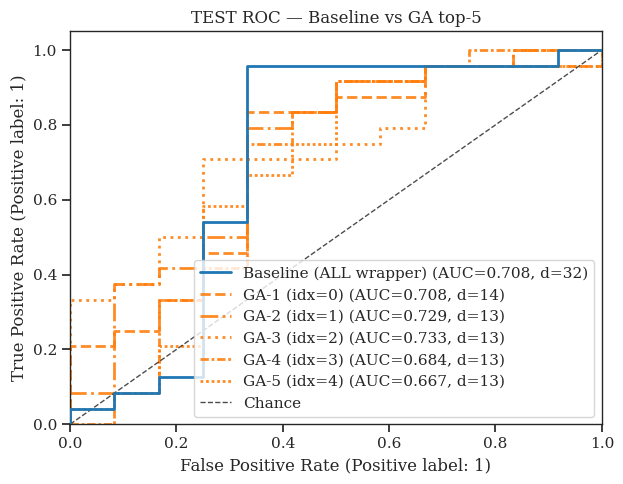


===== SUMMARY: Baseline + GA top-5 (CV & TEST) =====
                     name  n_features  cv_auc_best  cv_auc_mean  cv_auc_std  \
0  Baseline (ALL wrapper)          32     0.873333     0.873333    0.088377   
1            GA-1 (idx=0)          14     0.823939     0.823939    0.080154   
2            GA-2 (idx=1)          13     0.843030     0.843030    0.104840   
3            GA-3 (idx=2)          13     0.843636     0.843636    0.129782   
4            GA-4 (idx=3)          13     0.853333     0.853333    0.078568   
5            GA-5 (idx=4)          13     0.870909     0.870909    0.072818   

   test_auc  
0  0.708333  
1  0.708333  
2  0.729167  
3  0.732639  
4  0.684028  
5  0.666667  


In [59]:
# Cell 3: Final train on FULL TRAIN + TEST ROC (Baseline + GA top-5)

plt.figure(figsize=(6.4, 5.0))

test_rows = []

# Colors: one for Baseline, one shared color for all GA subsets
COLOR_BASELINE = "tab:blue"   # unique color for Baseline
COLOR_GA       = "tab:orange" # shared color for all GA feature sets

# Different linestyles for GA-1 ... GA-5 (same color, different pattern)
GA_LINESTYLES = [
    "--",              # GA-1
    "-.",              # GA-2
    ":",               # GA-3
    (0, (3, 1, 1, 1)), # GA-4 (custom dash pattern)
    (0, (1, 1)),       # GA-5 (dense dash)
]

ga_idx = 0  # index to assign linestyles for GA subsets

for fs in feature_sets:
    cols   = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xte_sub = X_test.iloc[:,  cols].to_numpy()

    clf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )
    clf.fit(Xtr_sub, y_np)
    prob_te = clf.predict_proba(Xte_sub)[:, 1]

    auc_te = roc_auc_score(y_te, prob_te)
    fpr, tpr, _ = roc_curve(y_te, prob_te)

    # Style for Baseline vs GA subsets
    if fs["name"].lower().startswith("baseline"):
        # Baseline: thick, solid, fully opaque, highest z-order
        curve_color = COLOR_BASELINE
        line_style  = "-"
        alpha       = 1.0
        z           = 3
    else:
        # GA subsets: same color, different linestyles, slightly thinner
        curve_color = COLOR_GA
        # Safeguard: if more GA sets than styles, wrap around
        line_style  = GA_LINESTYLES[min(ga_idx, len(GA_LINESTYLES) - 1)]
        alpha       = 0.9
        z           = 2
        ga_idx += 1

    label = f"{fs['name']} (AUC={auc_te:.3f}, d={len(cols)})"

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=label,
        color=curve_color,
        linestyle=line_style,
        alpha=alpha,
        zorder=z,
    )

    test_rows.append({
        "name": fs["name"],
        "n_features": int(len(cols)),
        "cv_auc_mean": float(fs.get("cv_auc_mean", np.nan)),
        "cv_auc_std":  float(fs.get("cv_auc_std",  np.nan)),
        "cv_auc_best": float(fs.get("cv_auc", np.nan)),  # from tuning
        "test_auc":    float(auc_te),
    })

# Chance line
plt.plot([0, 1], [0, 1], "--", lw=1, label="Chance", color="black", alpha=0.7)

plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel("False Positive Rate (Positive label: 1)")
plt.ylabel("True Positive Rate (Positive label: 1)")
plt.title("TEST ROC — Baseline vs GA top-5")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(test_rows)
print("\n===== SUMMARY: Baseline + GA top-5 (CV & TEST) =====")
print(results_df[["name", "n_features", "cv_auc_best", "cv_auc_mean", "cv_auc_std", "test_auc"]])


In [60]:
import seaborn as sns 
# 0) GA-only feature sets (exclude Baseline)
ga_feature_sets = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga_feature_sets) == 0:
    raise ValueError("No GA feature sets found in feature_sets (expected names starting with 'GA-').")

# 1) Lookup tables from auc_table / sens_table
#    - auc_table columns: "subset", "cv_auc_mean_over_folds", "cv_auc_std_over_folds"
#    - sens_table columns: "subset", "sensitivity_mean_at_0.5", "sensitivity_std_at_0.5"
auc_lookup  = {row["subset"]: row for _, row in auc_table.iterrows()}
sens_lookup = {row["subset"]: row for _, row in sens_table.iterrows()}

# 2) Attach CV AUC / sensitivity stats into each GA feature set dict
for fs in ga_feature_sets:
    name = fs["name"]

    # ---- CV AUC mean / std (from nested CV table) ----
    auc_row = auc_lookup.get(name, None)
    if auc_row is not None:
        fs["cv_auc_mean"] = float(auc_row["cv_auc_mean_over_folds"])
        fs["cv_auc_std"]  = float(auc_row["cv_auc_std_over_folds"])
    else:
        fs["cv_auc_mean"] = float("nan")
        fs["cv_auc_std"]  = float("nan")

    # ---- Sensitivity mean / std at threshold 0.5 ----
    sens_row = sens_lookup.get(name, None)
    if sens_row is not None:
        fs["sensitivity_mean_at_0.5"] = float(sens_row["sensitivity_mean_at_0.5"])
        fs["sensitivity_std_at_0.5"]  = float(sens_row["sensitivity_std_at_0.5"])
    else:
        fs["sensitivity_mean_at_0.5"] = float("nan")
        fs["sensitivity_std_at_0.5"]  = float("nan")

# 3) Filter candidates by sensitivity >= 0.8
SENS_MIN = 0.80
eligible = [
    fs for fs in ga_feature_sets
    if np.isfinite(fs.get("sensitivity_mean_at_0.5", np.nan))
    and fs["sensitivity_mean_at_0.5"] >= SENS_MIN
    and np.isfinite(fs.get("cv_auc_mean", np.nan))
]

if len(eligible) == 0:
    raise ValueError(f"No GA subsets meet sensitivity >= {SENS_MIN:.2f}. Consider lowering SENS_MIN or checking sens_table.")

# 4) Choose the subset whose CV train AUC is closest to the median among eligible candidates
eligible_cv_means = np.array([fs["cv_auc_mean"] for fs in eligible], dtype=float)
target_median = float(np.median(eligible_cv_means))

# Primary key: abs distance to median
# Tiebreakers: lower AUC std, then fewer features (optional but reasonable)
best_ga = min(
    eligible,
    key=lambda fs: (
        abs(fs["cv_auc_mean"] - target_median),
        fs.get("cv_auc_std", np.inf),
        len(fs["cols"]),
    )
)

# 5) Print summary
print("[INFO] Eligible GA candidates (sensitivity >= {:.2f}):".format(SENS_MIN))
for fs in sorted(eligible, key=lambda x: x["cv_auc_mean"]):
    print(
        f"  {fs['name']}: d={len(fs['cols']):2d}, "
        f"CV AUC={fs['cv_auc_mean']:.4f} ± {fs.get('cv_auc_std', float('nan')):.4f}, "
        f"sens@0.5={fs['sensitivity_mean_at_0.5']:.4f}"
    )

print("\n[INFO] Median CV AUC among eligible:", target_median)
print("[INFO] Chosen for SHAP (closest to median CV AUC):")
print(" name      :", best_ga["name"])
print(" n_features:", len(best_ga["cols"]))
print(" CV AUC    :", best_ga["cv_auc_mean"], "±", best_ga.get("cv_auc_std", float("nan")))
print(" sens@0.5  :", best_ga.get("sensitivity_mean_at_0.5", float("nan")))

[INFO] Eligible GA candidates (sensitivity >= 0.80):
  GA-1 (idx=0): d=14, CV AUC=0.8239 ± 0.0802, sens@0.5=0.9818
  GA-2 (idx=1): d=13, CV AUC=0.8430 ± 0.1048, sens@0.5=0.9636
  GA-3 (idx=2): d=13, CV AUC=0.8436 ± 0.1298, sens@0.5=0.8527
  GA-4 (idx=3): d=13, CV AUC=0.8533 ± 0.0786, sens@0.5=0.9636
  GA-5 (idx=4): d=13, CV AUC=0.8709 ± 0.0728, sens@0.5=0.9455

[INFO] Median CV AUC among eligible: 0.8436363636363637
[INFO] Chosen for SHAP (closest to median CV AUC):
 name      : GA-3 (idx=2)
 n_features: 13
 CV AUC    : 0.8436363636363637 ± 0.12978190365405257
 sens@0.5  : 0.8527272727272728


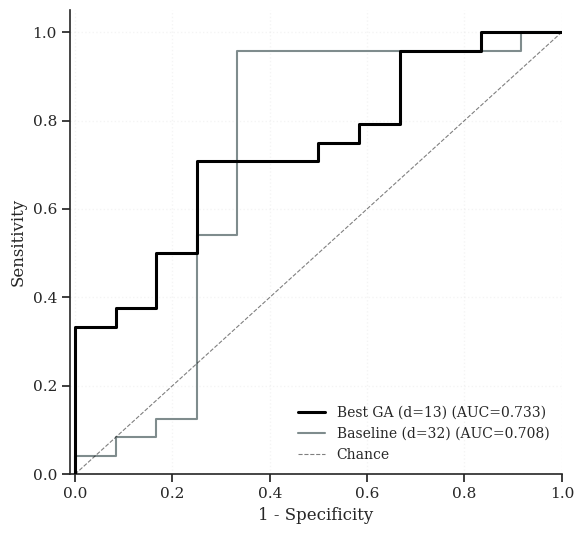

✅ 축 이름이 통일된 결과가 저장되었습니다: rf_svm_13\Final_ROC_d13_Unified.png


In [61]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# ---------------------------------------------------------
# 1. 저장 폴더 및 논문 스타일 설정 (rf_svm_13)
# ---------------------------------------------------------
save_folder = "rf_svm_13"
os.makedirs(save_folder, exist_ok=True)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.2
plt.figure(figsize=(6, 5.5))

# ---------------------------------------------------------
# 2. 모델 평가 및 비교 (d=13 vs d=32)
# ---------------------------------------------------------
# Baseline 찾기
baseline_fs = next(fs for fs in feature_sets if fs["name"].lower().startswith("baseline"))

# 라벨 통일: 차원수(d) 명시
plot_sets = [
    {"data": best_ga, "label_name": "Best GA (d=13)"},
    {"data": baseline_fs, "label_name": "Baseline (d=32)"}
]

for item in plot_sets:
    fs = item["data"]
    display_name = item["label_name"]
    
    cols = np.asarray(fs["cols"], dtype=int)
    params = dict(fs["best_params"])

    Xtr_sub = X_train.iloc[:, cols].to_numpy()
    Xte_sub = X_test.iloc[:, cols].to_numpy()

    # RandomForest 모델 학습
    clf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params
    )
    clf.fit(Xtr_sub, y_np)
    prob_te = clf.predict_proba(Xte_sub)[:, 1]

    auc_te = roc_auc_score(y_te, prob_te)
    fpr, tpr, _ = roc_curve(y_te, prob_te)

    # 스타일: GA는 검정 실선, Baseline은 회색 실선
    if "GA" in display_name:
        color, lw, z = "#000000", 2.2, 3
    else:
        color, lw, z = "#7f8c8d", 1.5, 1

    plt.plot(fpr, tpr, lw=lw, label=f"{display_name} (AUC={auc_te:.3f})", color=color, zorder=z)

# ---------------------------------------------------------
# 3. 플롯 마무리 (축 이름 통일: Specificity & Sensitivity)
# ---------------------------------------------------------
plt.plot([0, 1], [0, 1], color='black', lw=0.8, ls='--', alpha=0.5, label="Chance")

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])

# 축 이름을 Sensitivity와 1-Specificity로 통일
plt.xlabel("1 - Specificity", fontsize=12) 
plt.ylabel("Sensitivity", fontsize=12)

plt.legend(loc="lower right", fontsize=10, frameon=False)
plt.grid(alpha=0.2, ls=':')
sns.despine()
plt.tight_layout()

# ---------------------------------------------------------
# 4. 저장
# ---------------------------------------------------------
save_path = os.path.join(save_folder, "Final_ROC_d13_Unified.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 축 이름이 통일된 결과가 저장되었습니다: {save_path}")

[INFO] Bootstrapping for GA-3 (idx=2)...

 MODEL: GA-3 (idx=2) (Best GA-subset)
--------------------------------------------------
 Observed AUC:      0.7083
 Bootstrap Mean:    0.7096 ± 0.1195
 95% CI Range:      [0.4649, 0.9306]


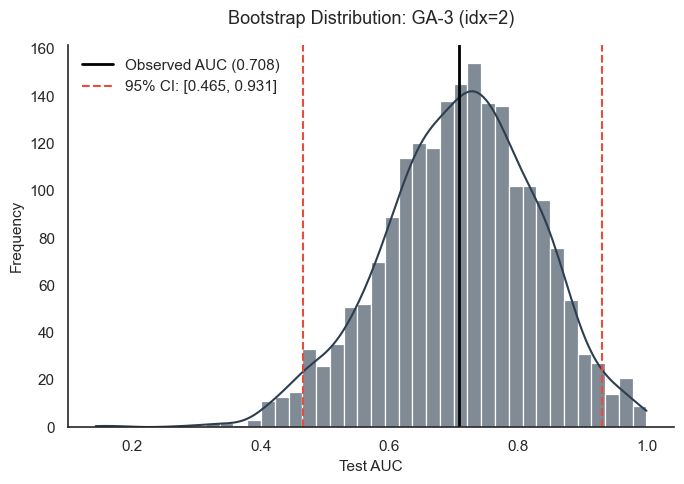

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import seaborn as sns

# ----------------------------
# 1) 기존 결과 데이터 준비 (이전 단계의 변수 활용)
# ----------------------------
# 이전 코드에서 계산된 y_te(실제값)와 prob_te(GA 모델의 예측 확률)를 사용합니다.
y_true = np.asarray(y_te)
scores = np.asarray(prob_te)  # binary case: (n_samples,) 형태

# 점 추정치 (Original AUC)
observed_auc = roc_auc_score(y_true, scores)

# ----------------------------
# 2) Bootstrap AUC distribution
# ----------------------------
B = 2000 
rng = np.random.default_rng(2026) 
n = len(y_true)
boot_stats = []

print(f"[INFO] Bootstrapping for {best_ga['name']}...")

for b in range(B):
    # 중복 허용 랜덤 샘플링
    idx = rng.integers(0, n, size=n)
    y_b = y_true[idx]
    s_b = scores[idx]

    # 샘플링된 데이터에 두 클래스가 모두 포함되어 있는지 확인 (AUC 계산 필수 조건)
    if len(np.unique(y_b)) < 2:
        continue

    auc_b = roc_auc_score(y_b, s_b)
    boot_stats.append(auc_b)

boot_stats = np.array(boot_stats)

# 95% 신뢰구간 (Percentile Method)
lo, hi = np.percentile(boot_stats, [2.5, 97.5])
mu = np.mean(boot_stats)
std = np.std(boot_stats, ddof=1)

# ----------------------------
# 3) 결과 출력
# ----------------------------
print("\n" + "="*50)
print(f" MODEL: {best_ga['name']} (Best GA-subset)")
print("-"*50)
print(f" Observed AUC:      {observed_auc:.4f}")
print(f" Bootstrap Mean:    {mu:.4f} ± {std:.4f}")
print(f" 95% CI Range:      [{lo:.4f}, {hi:.4f}]")
print("="*50)

# ----------------------------
# 4) 시각화 (Paper Style)
# ----------------------------
plt.figure(figsize=(7, 5))
sns.set_style("white") # 깔끔한 배경

# 히스토그램 및 밀도 곡선
sns.histplot(boot_stats, bins=40, kde=True, color="#2c3e50", alpha=0.6, edgecolor='white')

# 통계 지표 표시
plt.axvline(observed_auc, color='black', lw=2, label=f'Observed AUC ({observed_auc:.3f})')
plt.axvline(lo, color='#e74c3c', lw=1.5, ls='--', label=f'95% CI: [{lo:.3f}, {hi:.3f}]')
plt.axvline(hi, color='#e74c3c', lw=1.5, ls='--')

# 차트 디테일
plt.title(f"Bootstrap Distribution: {best_ga['name']}", fontsize=13, pad=15)
plt.xlabel("Test AUC", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.legend(frameon=False, loc='upper left')

sns.despine() # 테두리 제거
plt.tight_layout()
plt.show()

[GA-Best] AUC: 0.7326 (95% CI: 0.5437 - 0.8864)
[Baseline] AUC: 0.7083 (95% CI: 0.4649 - 0.9306)

📂 모든 결과가 'rf_svm_13' 폴더 내에 저장되었습니다.


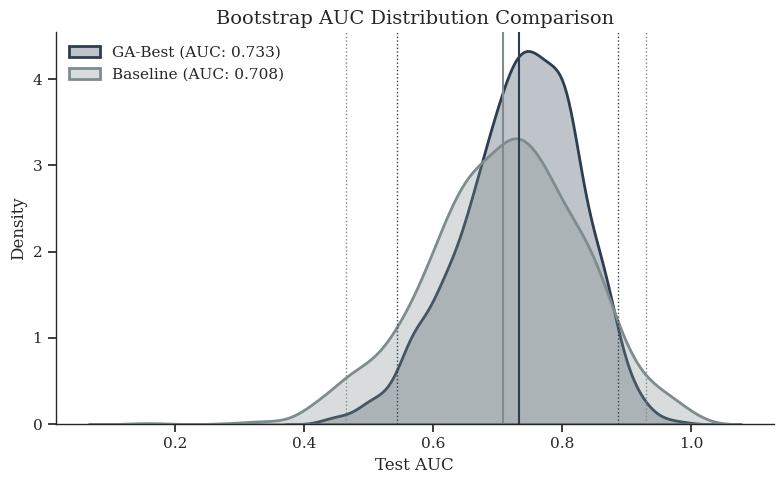

In [83]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# 0. 폴더 생성 설정
folder_path = "rf_svm_13"
os.makedirs(folder_path, exist_ok=True)

# ---------------------------------------------------------
# 1. GA-Best 모델: 선택된 컬럼 + 최적 파라미터
# ---------------------------------------------------------
cols_ga = np.asarray(best_ga["cols"], dtype=int)
params_ga = dict(best_ga["best_params"])

Xtr_ga = X_train.iloc[:, cols_ga].to_numpy()
Xte_ga = X_test.iloc[:, cols_ga].to_numpy()

clf_ga = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params_ga)
clf_ga.fit(Xtr_ga, y_np)
prob_ga = clf_ga.predict_proba(Xte_ga)[:, 1]

# ---------------------------------------------------------
# 2. Baseline 모델: 모든 컬럼 사용
# ---------------------------------------------------------
Xtr_bl = X_train.to_numpy()
Xte_bl = X_test.to_numpy()
params_bl = dict(baseline_fs["best_params"]) 

clf_bl = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **params_bl)
clf_bl.fit(Xtr_bl, y_np)
prob_bl = clf_bl.predict_proba(Xte_bl)[:, 1]

# ---------------------------------------------------------
# 3. 부트스트랩 함수 정의
# ---------------------------------------------------------
def get_bootstrap_auc(y_true, y_prob, n_bootstrap=2000):
    rng = np.random.default_rng(2026)
    boot_stats = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        y_b, s_b = y_true[idx], y_prob[idx]
        if len(np.unique(y_b)) < 2: continue
        boot_stats.append(roc_auc_score(y_b, s_b))
    return np.array(boot_stats)

# ---------------------------------------------------------
# 4. 각각 부트스트랩 실행 및 통계량 계산
# ---------------------------------------------------------
y_true_arr = np.asarray(y_te)
boot_ga = get_bootstrap_auc(y_true_arr, prob_ga)
boot_bl = get_bootstrap_auc(y_true_arr, prob_bl)

stats = []
# 텍스트 결과 저장을 위해 파일 열기
with open(os.path.join(folder_path, "auc_statistics.txt"), "w") as f:
    for name, boot in [("GA-Best", boot_ga), ("Baseline", boot_bl)]:
        lo, hi = np.percentile(boot, [2.5, 97.5])
        mu = np.mean(boot)
        observed = roc_auc_score(y_true_arr, prob_ga if name=="GA-Best" else prob_bl)
        stats.append({"name": name, "obs": observed, "lo": lo, "hi": hi, "mu": mu, "boot": boot})
        
        result_str = f"[{name}] AUC: {observed:.4f} (95% CI: {lo:.4f} - {hi:.4f})"
        print(result_str)
        f.write(result_str + "\n")

# ---------------------------------------------------------
# 5. 시각화 및 저장
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
colors = {"GA-Best": "#2c3e50", "Baseline": "#7f8c8d"}

for s in stats:
    sns.kdeplot(s["boot"], label=f"{s['name']} (AUC: {s['obs']:.3f})", 
                color=colors[s['name']], fill=True, alpha=0.3, lw=2)
    plt.axvline(s['obs'], color=colors[s['name']], ls='-', lw=1.5)
    plt.axvline(s['lo'], color=colors[s['name']], ls=':', lw=1)
    plt.axvline(s['hi'], color=colors[s['name']], ls=':', lw=1)

plt.title("Bootstrap AUC Distribution Comparison", fontsize=14)
plt.xlabel("Test AUC", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()

# 그래프 저장 (show 하기 전에 실행)
plt.savefig(os.path.join(folder_path, "auc_bootstrap_plot.png"), dpi=300)
print(f"\n📂 모든 결과가 '{folder_path}' 폴더 내에 저장되었습니다.")

plt.show()

In [64]:
import os
import numpy as np
# ---------------------------------------------------------
# 1. 초기 설정: 폴더 및 논문용 스타일 (Serif 폰트)
# ---------------------------------------------------------
folder_path = "rf_svm_13"
os.makedirs(folder_path, exist_ok=True)
sns.set_theme(style="ticks", rc={"font.family": "serif"})
class_labels = ['Unmethylated', 'Methylated']

# ---------------------------------------------------------
# 2. 모델 예측값 생성 (변수가 정의되지 않았을 경우를 대비)
# ---------------------------------------------------------

# A: Baseline 모델 (모든 피처 사용)
Xtr_all = X_train.to_numpy()
Xte_all = X_test.to_numpy()
clf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **baseline_fs["best_params"])
clf_base.fit(Xtr_all, y_np)
y_pred_baseline = clf_base.predict(Xte_all)

# B: Best GA 모델 (선택된 d개 피처 사용)
cols_ga = np.asarray(best_ga["cols"], dtype=int)
Xtr_ga = X_train.iloc[:, cols_ga].to_numpy()
Xte_ga = X_test.iloc[:, cols_ga].to_numpy()
clf_ga = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_ga["best_params"])
clf_ga.fit(Xtr_ga, y_np)
y_pred_ga = clf_ga.predict(Xte_ga)

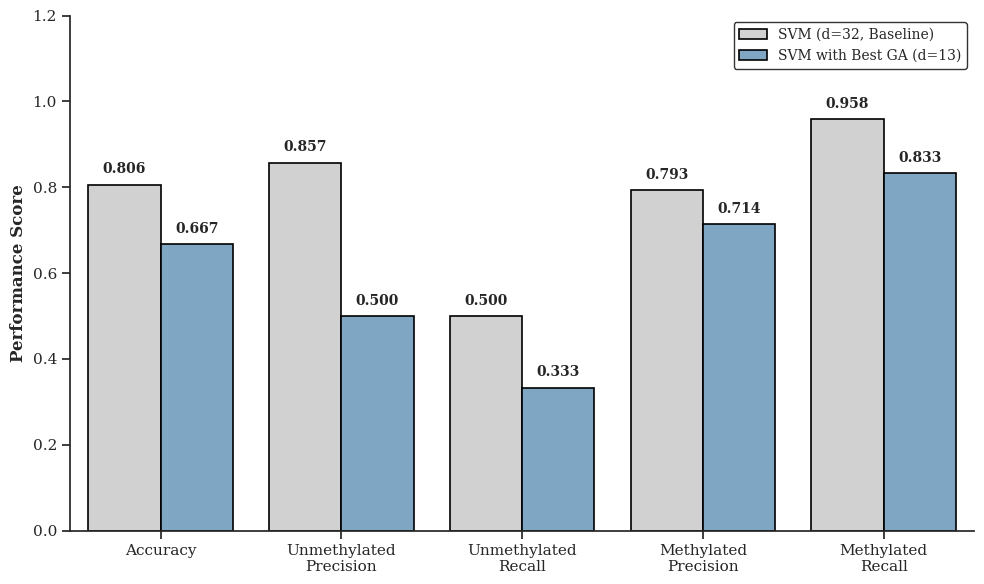

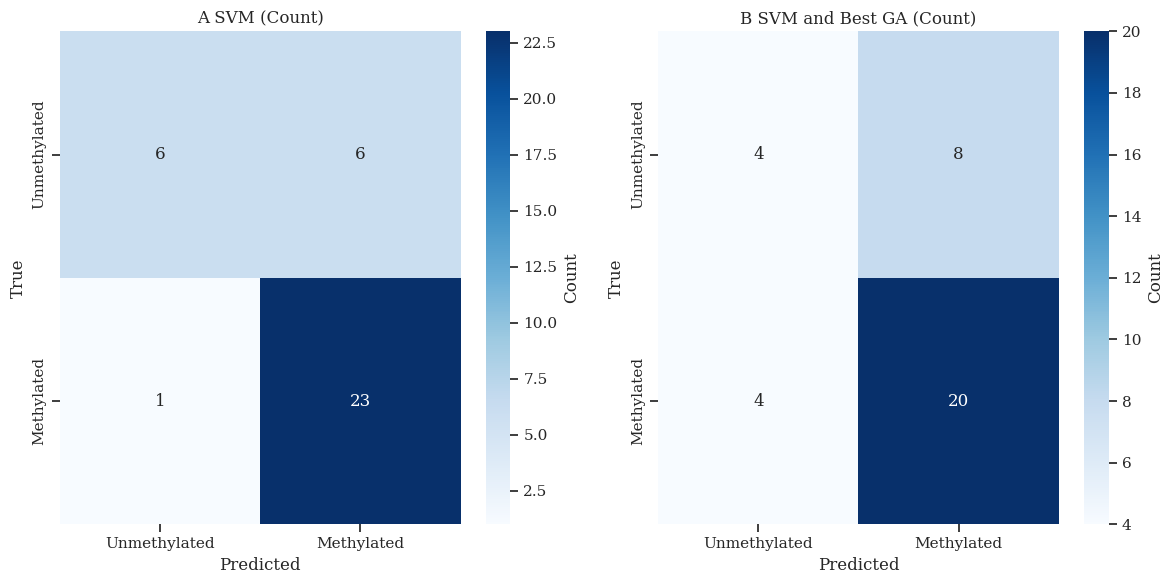

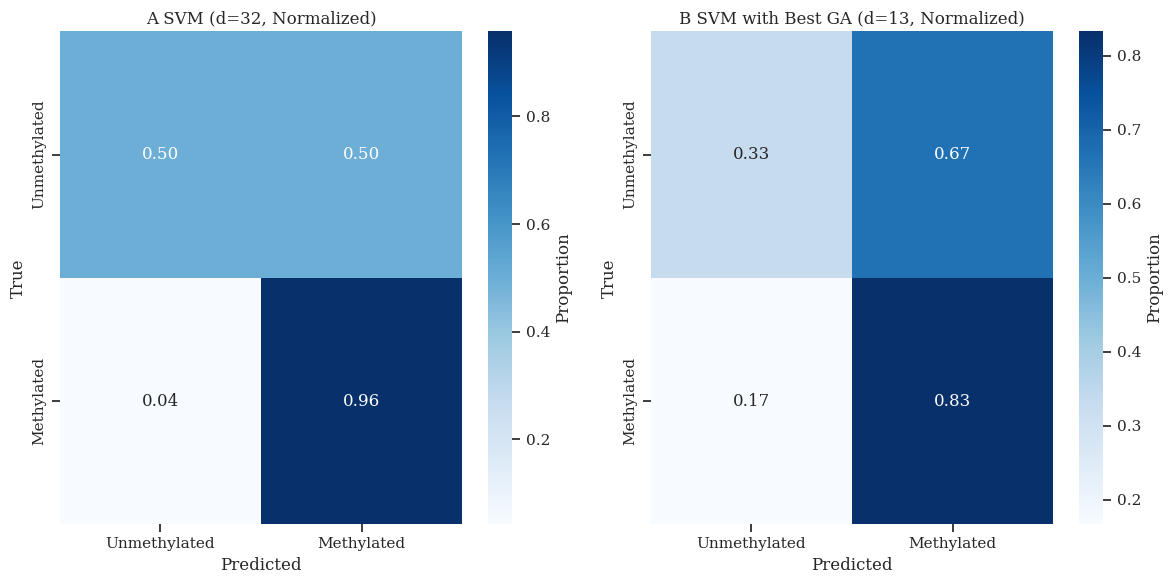

In [65]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, accuracy_score, confusion_matrix

# ---------------------------------------------------------
# 1. 초기 설정: 폴더 생성 및 스타일 적용
# ---------------------------------------------------------
folder_path = "rf_svm_13"
os.makedirs(folder_path, exist_ok=True)

# 폰트 오류 방지를 위한 rc 설정 (Serif 폰트 적용)
sns.set_theme(style="ticks", rc={"font.family": "serif"})
class_labels = ['Unmethylated', 'Methylated']

# ---------------------------------------------------------
# 2. 성능 데이터 계산 및 구조화 (Bar Chart용)
# ---------------------------------------------------------
# y_pred_baseline과 y_pred_ga(Best GA d=13 결과)를 사용합니다.
metrics_data = {
    'Metric': [
        'Accuracy', 'Unmethylated\nPrecision', 'Unmethylated\nRecall', 
        'Methylated\nPrecision', 'Methylated\nRecall'
    ] * 2,
    'Score': [
        # SVM (Baseline)
        accuracy_score(y_test, y_pred_baseline), 
        precision_score(y_test, y_pred_baseline, average=None)[0],
        recall_score(y_test, y_pred_baseline, average=None)[0],
        precision_score(y_test, y_pred_baseline, average=None)[1],
        recall_score(y_test, y_pred_baseline, average=None)[1],
        # SVM with Best GA (d=13)
        accuracy_score(y_test, y_pred_ga), 
        precision_score(y_test, y_pred_ga, average=None)[0],
        recall_score(y_test, y_pred_ga, average=None)[0],
        precision_score(y_test, y_pred_ga, average=None)[1],
        recall_score(y_test, y_pred_ga, average=None)[1]
    ],
    'Model': ['SVM (d=32, Baseline)'] * 5 + ['SVM with Best GA (d=13)'] * 5
}
df_metrics = pd.DataFrame(metrics_data)

# --- Metric Bar Chart 생성 및 저장 ---
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df_metrics, x='Metric', y='Score', hue='Model', 
    palette=['#d1d1d1', '#74a9cf'], edgecolor='black', linewidth=1.2
)

ax_bar.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
ax_bar.set_xlabel('')
ax_bar.set_ylim(0, 1.2)
sns.despine()

for container in ax_bar.containers:
    ax_bar.bar_label(container, fmt='%.3f', padding=6, weight='bold', size=10)

plt.legend(frameon=True, loc='upper right', fontsize=10, edgecolor='black')
plt.tight_layout()
plt.savefig(os.path.join(folder_path, "SVM_13_Metrics.png"), dpi=300)
plt.show()

# ---------------------------------------------------------
# 3. Confusion Matrix 계산 및 시각화
# ---------------------------------------------------------
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=[0, 1])
cm_best_ga = confusion_matrix(y_test, y_pred_ga, labels=[0, 1])

# 정규화 버전 생성
cm_baseline_norm = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]
cm_best_ga_norm = cm_best_ga.astype('float') / cm_best_ga.sum(axis=1)[:, np.newaxis]

# --- A: Count Confusion Matrix 저장 ---
fig_count, axes_count = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Count'}, ax=axes_count[0])
axes_count[0].set_title("A SVM (Count)")
axes_count[0].set_xlabel("Predicted")
axes_count[0].set_ylabel("True")

sns.heatmap(cm_best_ga, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Count'}, ax=axes_count[1])
axes_count[1].set_title("B SVM and Best GA (Count)")
axes_count[1].set_xlabel("Predicted")
axes_count[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(os.path.join(folder_path, "BestGa_confusion_matrices_SVM_count.png"), dpi=300)

# --- B: Normalized Confusion Matrix 저장 ---
fig_norm, axes_norm = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(cm_baseline_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Proportion'}, ax=axes_norm[0])
axes_norm[0].set_title("A SVM (d=32, Normalized)")
axes_norm[0].set_xlabel("Predicted")
axes_norm[0].set_ylabel("True")

sns.heatmap(cm_best_ga_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Proportion'}, ax=axes_norm[1])
axes_norm[1].set_title("B SVM with Best GA (d=13, Normalized)")
axes_norm[1].set_xlabel("Predicted")
axes_norm[1].set_ylabel("True")


plt.tight_layout()
plt.savefig(os.path.join(folder_path, "BestGa_confusion_matrices_SVM_normalized.png"), dpi=300)

plt.show()

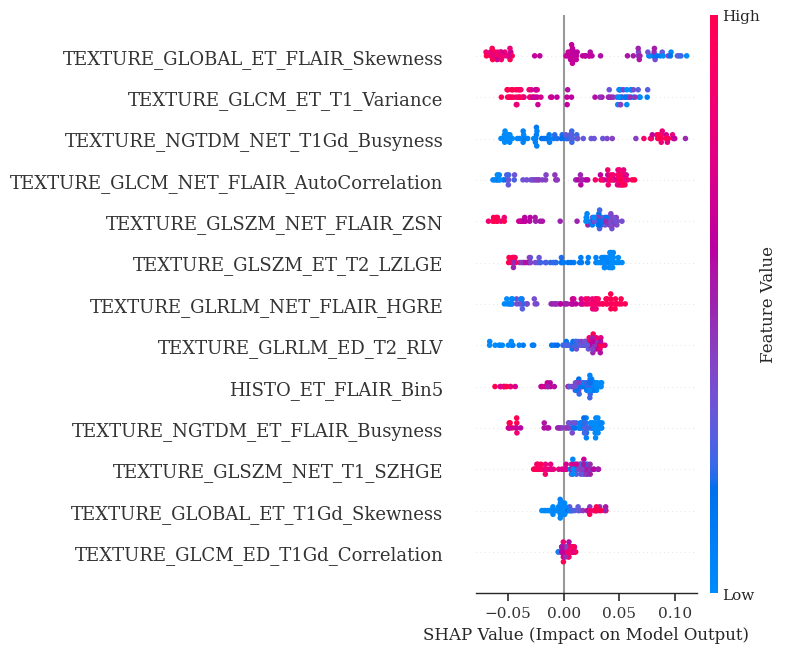

[INFO] SHAP Summary Plot이 저장되었습니다: rf_svm_13\Figure_SHAP_Summary.png


In [66]:
import os
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# 1. 저장 폴더 및 스타일 설정
# ---------------------------------------------------------
save_folder = "rf_svm_13"
os.makedirs(save_folder, exist_ok=True)

# 논문용 폰트 설정
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.0

# ---------------------------------------------------------
# 2. 모델 학습 (Best GA Subset)
# ---------------------------------------------------------
ga_cols   = np.asarray(best_ga["cols"], dtype=int)
ga_params = dict(best_ga["best_params"])

Xtr_ga = X_train.iloc[:, ga_cols]
y_tr   = y_train.to_numpy().ravel()

rf_ga_shap = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    **ga_params
)
rf_ga_shap.fit(Xtr_ga, y_tr)

# ---------------------------------------------------------
# 3. SHAP 계산
# ---------------------------------------------------------
explainer = shap.TreeExplainer(rf_ga_shap)
shap_values = explainer.shap_values(Xtr_ga)

# RandomForest의 경우 클래스 0, 1에 대한 값이 리스트로 반환될 수 있음
# 이진 분류에서 Positive(1) 클래스에 대한 영향력 선택
if isinstance(shap_values, list):
    # scikit-learn RF는 보통 [samples, features, classes] 혹은 list of [samples, features]
    vals_to_plot = shap_values[1]
else:
    # 3차원 배열인 경우 [samples, features, class_index]
    vals_to_plot = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

# ---------------------------------------------------------
# 4. 시각화 및 저장
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# SHAP Summary Plot 생성
# show=False로 설정해야 저장이 가능합니다.
shap.summary_plot(
    vals_to_plot, 
    Xtr_ga, 
    feature_names=Xtr_ga.columns,
    plot_type="dot", 
    show=False
)

# 논문 스타일을 위한 미세 조정
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.gcf().axes[-1].set_ylabel("Feature Value", fontsize=12) # Colorbar label

# 여백 조정 및 저장
plt.tight_layout()
save_path = os.path.join(save_folder, "Figure_SHAP_Summary.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] SHAP Summary Plot이 저장되었습니다: {save_path}")

[INFO] Top 3 Features: ['TEXTURE_GLOBAL_ET_FLAIR_Skewness', 'TEXTURE_GLCM_ET_T1_Variance', 'TEXTURE_NGTDM_NET_T1Gd_Busyness']


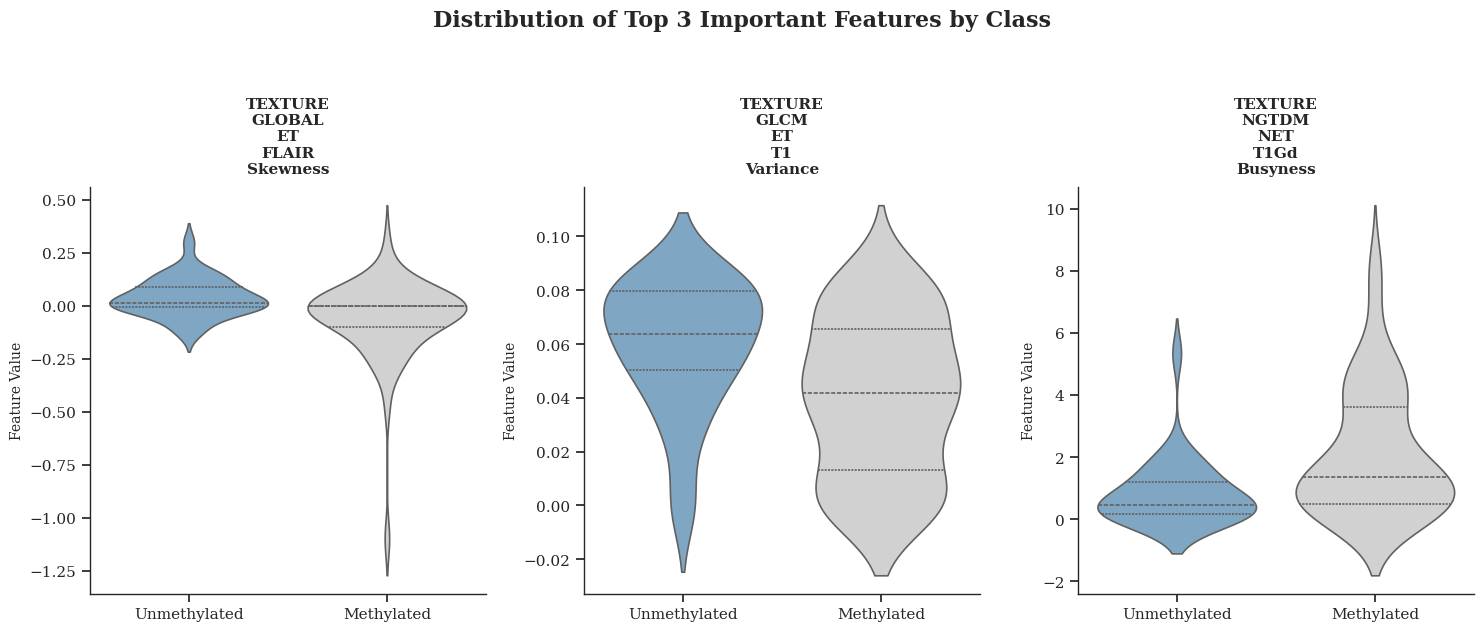

[INFO] Saved the updated Top 3 violin plots to: rf_svm_13\Figure_Top3_ViolinPlots_Separate.png


In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# 1. Extract Top 3 features based on SHAP values
# ---------------------------------------------------------
# Calculate the mean absolute SHAP value for each feature
shap_importance = np.abs(vals_to_plot).mean(axis=0)

# Sort and get the indices of the top 3 features
top3_indices = np.argsort(shap_importance)[::-1][:3]
top3_features = Xtr_ga.columns[top3_indices]

print(f"[INFO] Top 3 Features: {list(top3_features)}")

# ---------------------------------------------------------
# 2. Prepare data for plotting
# ---------------------------------------------------------
# Extract only the top 3 features
df_top3 = Xtr_ga[top3_features].copy()

# Add class labels mapping (0: Unmethylated, 1: Methylated)
class_labels_dict = {0: 'Unmethylated', 1: 'Methylated'}
df_top3['Class'] = [class_labels_dict[val] for val in y_tr]

# ---------------------------------------------------------
# 3. Create Independent Subplots for each feature
# ---------------------------------------------------------
# Create a 1x3 grid of subplots to allow independent Y-axes
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Custom palette consistent with previous plots
my_palette = {'Unmethylated': '#74a9cf', 'Methylated': '#d1d1d1'}

for i, feature in enumerate(top3_features):
    # Plot violin plot for each feature on its own axis
    sns.violinplot(
        data=df_top3, 
        x='Class',           # X-axis represents the two classes
        y=feature,           # Y-axis is the specific feature's value
        ax=axes[i],
        palette=my_palette,
        inner="quart",       # Show quartiles inside the violin
        linewidth=1.2,
        hue='Class',         # <--- 추가: x축과 동일하게 hue를 지정합니다.
        legend=False,
        order=['Unmethylated', 'Methylated'] # Maintain consistent order
    )
    
    # Set the title to the feature name (wrap text if it's too long)
    # Replace underscores with spaces for better readability in the title
    display_title = feature.replace('_', '\n') 
    axes[i].set_title(display_title, fontsize=11, fontweight='bold', pad=10)
    
    # Clean up axis labels
    axes[i].set_ylabel("Feature Value", fontsize=10)
    axes[i].set_xlabel("")
    
    # Remove top and right borders for a cleaner look
    sns.despine(ax=axes[i])

# Add a main title for the entire figure
plt.suptitle("Distribution of Top 3 Important Features by Class", 
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()

# Save the figure
save_path_violin = os.path.join(save_folder, "Figure_Top3_ViolinPlots_Separate.png")
plt.savefig(save_path_violin, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] Saved the updated Top 3 violin plots to: {save_path_violin}")

[INFO] Top 3 Features: ['TEXTURE_GLOBAL_ET_FLAIR_Skewness', 'TEXTURE_GLCM_ET_T1_Variance', 'TEXTURE_NGTDM_NET_T1Gd_Busyness']


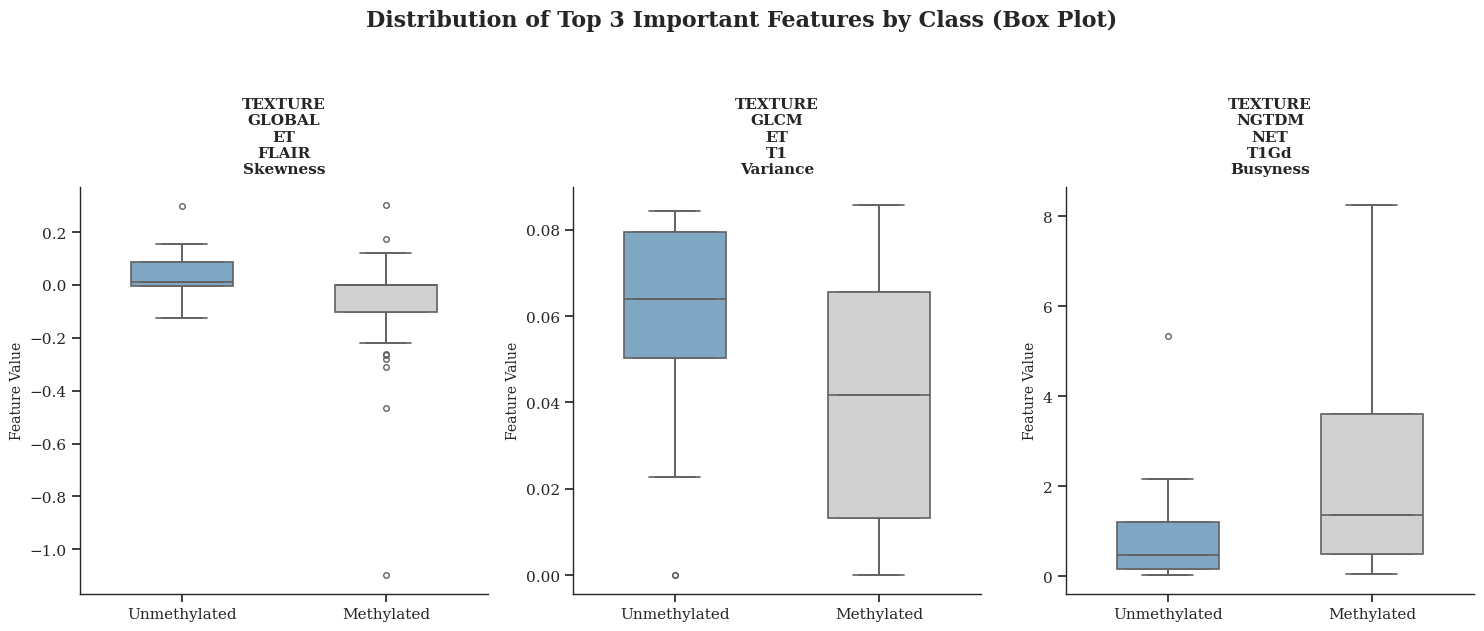

[INFO] Saved the Top 3 box plots to: rf_svm_13\Figure_Top3_BoxPlots_Separate.png


In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# 1. Extract Top 3 features based on SHAP values
# ---------------------------------------------------------
# Calculate the mean absolute SHAP value for each feature
shap_importance = np.abs(vals_to_plot).mean(axis=0)

# Sort and get the indices of the top 3 features
top3_indices = np.argsort(shap_importance)[::-1][:3]
top3_features = Xtr_ga.columns[top3_indices]

print(f"[INFO] Top 3 Features: {list(top3_features)}")

# ---------------------------------------------------------
# 2. Prepare data for plotting
# ---------------------------------------------------------
# Extract only the top 3 features
df_top3 = Xtr_ga[top3_features].copy()

# Add class labels mapping (0: Unmethylated, 1: Methylated)
class_labels_dict = {0: 'Unmethylated', 1: 'Methylated'}
df_top3['Class'] = [class_labels_dict[val] for val in y_tr]

# ---------------------------------------------------------
# 3. Create Independent Subplots for Box Plots
# ---------------------------------------------------------
# Create a 1x3 grid of subplots to allow independent Y-axes
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Custom palette consistent with previous plots
my_palette = {'Unmethylated': '#74a9cf', 'Methylated': '#d1d1d1'}

for i, feature in enumerate(top3_features):

    sns.boxplot(
        data=df_top3, x='Class', y=feature, hue='Class', legend=False,
        ax=axes[i], palette=my_palette, width=0.4, fliersize=0, # Hide outliers to avoid overlap
        linewidth=1.2, order=['Unmethylated', 'Methylated']
    )
    
    # # 2. Add individual data points (Jitter plot)
    # # This helps visualize exactly how many outliers are there
    # sns.stripplot(
    #     data=df_top3, x='Class', y=feature, 
    #     ax=axes[i], color='black', size=4, alpha=0.4, jitter=True,
    #     order=['Unmethylated', 'Methylated']
    # )
    # Plot box plot for each feature on its own axis
    sns.boxplot(
        data=df_top3, 
        x='Class',           
        y=feature,           
        hue='Class',         # Add hue to prevent seaborn deprecation warning
        legend=False,        # Hide duplicate legends
        ax=axes[i],
        palette=my_palette,
        width=0.5,           # Adjust the width of the boxes
        fliersize=4,         # Adjust the size of outlier points (diamonds/circles)
        linewidth=1.2,
        order=['Unmethylated', 'Methylated'] # Maintain consistent order
    )
    
    # Set the title to the feature name (wrap text for long names)
    display_title = feature.replace('_', '\n') 
    axes[i].set_title(display_title, fontsize=11, fontweight='bold', pad=10)
    
    # Clean up axis labels
    axes[i].set_ylabel("Feature Value", fontsize=10)
    axes[i].set_xlabel("")
    
    # Remove top and right borders for a cleaner look
    sns.despine(ax=axes[i])

# Add a main title for the entire figure
plt.suptitle("Distribution of Top 3 Important Features by Class (Box Plot)", 
             fontsize=16, fontweight='bold', y=1.05)

plt.tight_layout()

# Save the figure
save_path_box = os.path.join(save_folder, "Figure_Top3_BoxPlots_Separate.png")
plt.savefig(save_path_box, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] Saved the Top 3 box plots to: {save_path_box}")

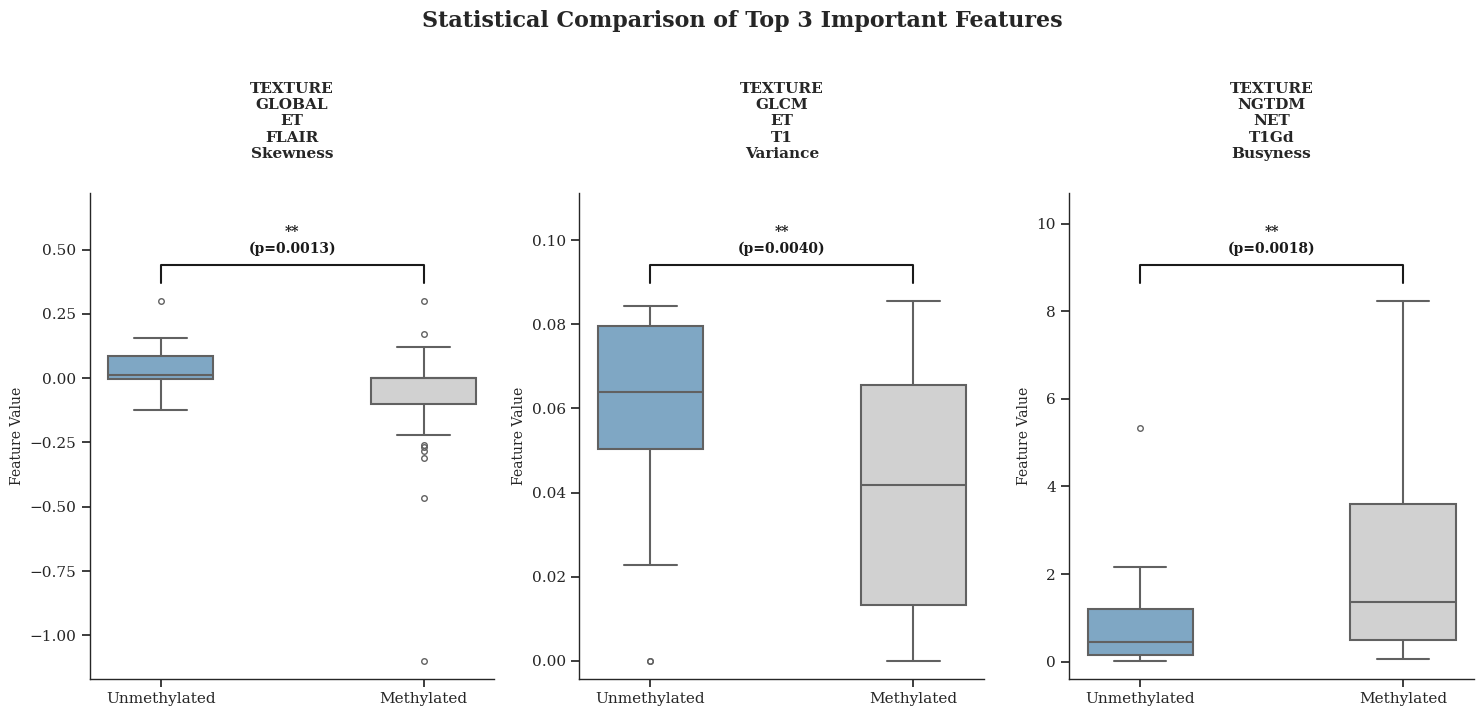

[INFO] Saved the Box Plots with p-values to: rf_svm_13\Figure_Top3_BoxPlots_with_Pvalue.png


In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import mannwhitneyu

# ---------------------------------------------------------
# 1. Extract Top 3 features based on SHAP values
# ---------------------------------------------------------
shap_importance = np.abs(vals_to_plot).mean(axis=0)
top3_indices = np.argsort(shap_importance)[::-1][:3]
top3_features = Xtr_ga.columns[top3_indices]

# ---------------------------------------------------------
# 2. Prepare data
# ---------------------------------------------------------
df_top3 = Xtr_ga[top3_features].copy()
class_labels_dict = {0: 'Unmethylated', 1: 'Methylated'}
df_top3['Class'] = [class_labels_dict[val] for val in y_tr]

# ---------------------------------------------------------
# 3. Visualization with Statistical Testing (Mann-Whitney U)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
my_palette = {'Unmethylated': '#74a9cf', 'Methylated': '#d1d1d1'}
order = ['Unmethylated', 'Methylated']

for i, feature in enumerate(top3_features):
    # Create Box Plot
    sns.boxplot(
        data=df_top3, x='Class', y=feature, hue='Class', legend=False,
        ax=axes[i], palette=my_palette, width=0.4, fliersize=4,
        linewidth=1.5, order=order
    )
    
    # Optional: Add individual points to show the actual distribution/outliers
    # sns.stripplot(
    #     data=df_top3, x='Class', y=feature, ax=axes[i], 
    #     color='black', size=3, alpha=0.3, jitter=True, order=order
    # )

    # --- Statistical Test (Mann-Whitney U) ---
    group1 = df_top3[df_top3['Class'] == 'Unmethylated'][feature]
    group2 = df_top3[df_top3['Class'] == 'Methylated'][feature]
    stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')

    # Determine significance level (Stars)
    if p_val < 0.001: sig = "***"
    elif p_val < 0.01: sig = "**"
    elif p_val < 0.05: sig = "*"
    else: sig = "n.s."

    # Annotation logic: Place the p-value at the top of the plot
    y_max = df_top3[feature].max()
    y_min = df_top3[feature].min()
    h = (y_max - y_min) * 0.05  # Height for the annotation line
    
    # Drawing the bracket and text
    axes[i].plot([0, 0, 1, 1], [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h], lw=1.5, c='k')
    axes[i].text(0.5, y_max + 2.5*h, f"{sig}\n(p={p_val:.4f})", 
                 ha='center', va='bottom', color='k', fontsize=10, fontweight='bold')

    # Styling
    display_title = feature.replace('_', '\n')
    axes[i].set_title(display_title, fontsize=11, fontweight='bold', pad=25)
    axes[i].set_ylabel("Feature Value", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylim(y_min - h, y_max + 6*h) # Adjust limit to fit annotation
    sns.despine(ax=axes[i])

plt.suptitle("Statistical Comparison of Top 3 Important Features", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save
save_path_stat = os.path.join(save_folder, "Figure_Top3_BoxPlots_with_Pvalue.png")
plt.savefig(save_path_stat, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] Saved the Box Plots with p-values to: {save_path_stat}")

[INFO] Top 3 Features for Scatter Matrix: ['TEXTURE_GLOBAL_ET_FLAIR_Skewness', 'TEXTURE_GLCM_ET_T1_Variance', 'TEXTURE_NGTDM_NET_T1Gd_Busyness']


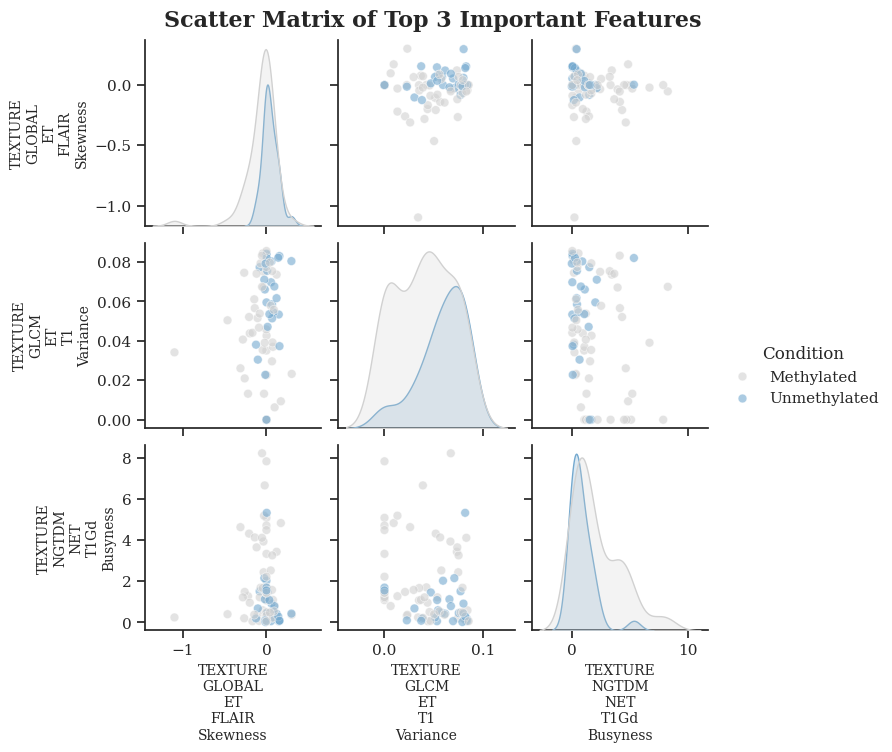

[INFO] Saved the Top 3 Scatter Matrix to: rf_svm_13\Figure_Top3_ScatterMatrix.png


In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ---------------------------------------------------------
# 1. Extract Top 3 features based on SHAP values
# ---------------------------------------------------------
# Calculate the mean absolute SHAP value for each feature
shap_importance = np.abs(vals_to_plot).mean(axis=0)

# Sort and get the indices of the top 3 features
top3_indices = np.argsort(shap_importance)[::-1][:3]
top3_features = Xtr_ga.columns[top3_indices]

print(f"[INFO] Top 3 Features for Scatter Matrix: {list(top3_features)}")

# ---------------------------------------------------------
# 2. Prepare data for the Scatter Matrix
# ---------------------------------------------------------
# Extract only the top 3 features
df_top3 = Xtr_ga[top3_features].copy()

# Add class labels mapping (0: Unmethylated, 1: Methylated)
class_labels_dict = {0: 'Unmethylated', 1: 'Methylated'}
df_top3['Condition'] = [class_labels_dict[val] for val in y_tr]

# To make the plot cleaner, rename columns to replace underscores with spaces/newlines
# This prevents labels from overlapping or being cut off
display_names = {col: col.replace('_', '\n') for col in top3_features}
df_plot = df_top3.rename(columns=display_names)
new_top3_cols = [display_names[col] for col in top3_features]

# ---------------------------------------------------------
# 3. Create Scatter Matrix (Pairplot)
# ---------------------------------------------------------
# Set the visual style
sns.set_theme(style="ticks", rc={"font.family": "serif"})
my_palette = {'Unmethylated': '#74a9cf', 'Methylated': '#d1d1d1'}

# Generate the pairplot
g = sns.pairplot(
    df_plot, 
    vars=new_top3_cols, 
    hue='Condition', 
    palette=my_palette,
    diag_kind='kde',      # Show density plots on the diagonal
    plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'w'}, # Scatter plot settings
    diag_kws={'fill': True} # Density plot settings
)

# Customizing titles and spacing
g.fig.suptitle("Scatter Matrix of Top 3 Important Features", 
               fontsize=16, fontweight='bold', y=1.02)

# Adjust label font sizes
for ax in g.axes.flatten():
    if ax is not None:
        ax.xaxis.label.set_size(10)
        ax.yaxis.label.set_size(10)

# ---------------------------------------------------------
# 4. Save the figure
# ---------------------------------------------------------
save_path_pair = os.path.join(save_folder, "Figure_Top3_ScatterMatrix.png")
plt.savefig(save_path_pair, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] Saved the Top 3 Scatter Matrix to: {save_path_pair}")

In [71]:
# Print the feature names used for SHAP (i.e., the GA-selected subset)
print(f"\n[INFO] SHAP features used (total={Xtr_ga.shape[1]}):")
for i, name in enumerate(Xtr_ga.columns, 1):
    print(f"{i:02d}. {name}")

# (Optional) Print as a single Python list for easy copy/paste
print("\n[INFO] Feature list:")
print(list(Xtr_ga.columns))



[INFO] SHAP features used (total=13):
01. HISTO_ET_FLAIR_Bin5
02. TEXTURE_GLOBAL_ET_T1Gd_Skewness
03. TEXTURE_GLOBAL_ET_FLAIR_Skewness
04. TEXTURE_GLCM_ET_T1_Variance
05. TEXTURE_GLCM_ED_T1Gd_Correlation
06. TEXTURE_GLCM_NET_FLAIR_AutoCorrelation
07. TEXTURE_GLRLM_ED_T2_RLV
08. TEXTURE_GLRLM_NET_FLAIR_HGRE
09. TEXTURE_GLSZM_ET_T2_LZLGE
10. TEXTURE_GLSZM_NET_T1_SZHGE
11. TEXTURE_GLSZM_NET_FLAIR_ZSN
12. TEXTURE_NGTDM_ET_FLAIR_Busyness
13. TEXTURE_NGTDM_NET_T1Gd_Busyness

[INFO] Feature list:
['HISTO_ET_FLAIR_Bin5', 'TEXTURE_GLOBAL_ET_T1Gd_Skewness', 'TEXTURE_GLOBAL_ET_FLAIR_Skewness', 'TEXTURE_GLCM_ET_T1_Variance', 'TEXTURE_GLCM_ED_T1Gd_Correlation', 'TEXTURE_GLCM_NET_FLAIR_AutoCorrelation', 'TEXTURE_GLRLM_ED_T2_RLV', 'TEXTURE_GLRLM_NET_FLAIR_HGRE', 'TEXTURE_GLSZM_ET_T2_LZLGE', 'TEXTURE_GLSZM_NET_T1_SZHGE', 'TEXTURE_GLSZM_NET_FLAIR_ZSN', 'TEXTURE_NGTDM_ET_FLAIR_Busyness', 'TEXTURE_NGTDM_NET_T1Gd_Busyness']


In [72]:
# Cell: build t-SNE embedding on GA-selected feature subset (train + test)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Cell: build t-SNE embedding on GA-selected feature subset (train + test)

RANDOM_STATE = 42

# 1) Use GA-selected feature indices from best_ga
ga_cols = np.asarray(best_ga["cols"], dtype=int)

# 2) Subset train / test features using the same GA subset
Xtr_ga = X_train.iloc[:, ga_cols]
Xte_ga = X_test.iloc[:, ga_cols]

# 3) Stack train + test into a single matrix for a joint t-SNE embedding
X_all_ga = np.vstack([Xtr_ga.to_numpy(), Xte_ga.to_numpy()])

# y_np, y_te are assumed to be defined earlier as 1D numpy arrays
y_all = np.concatenate([y_np, y_te])

# Indicator for train vs test (for plotting)
split_label = np.array(["train"] * len(y_np) + ["test"] * len(y_te))

print("[INFO] X_all_ga shape:", X_all_ga.shape)
print("[INFO] y_all length:", len(y_all))

# 4) Standardize features before running t-SNE
scaler = StandardScaler()
X_all_ga_scaled = scaler.fit_transform(X_all_ga)

# 5) Run t-SNE in 2D on GA-selected features
tsne = TSNE(
    n_components=2,
    perplexity=20,
    learning_rate="auto",
    init="random",
    n_iter=1000,
    random_state=RANDOM_STATE,
    verbose=1,
)
X_all_tsne = tsne.fit_transform(X_all_ga_scaled)

print("[INFO] t-SNE embedding shape:", X_all_tsne.shape)

# 6) Pack into a DataFrame for convenient plotting
tsne_df = pd.DataFrame({
    "tsne1": X_all_tsne[:, 0],
    "tsne2": X_all_tsne[:, 1],
    "label": y_all,
    "split": split_label,
})


[INFO] X_all_ga shape: (118, 13)
[INFO] y_all length: 118
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 118 samples in 0.000s...
[t-SNE] Computed neighbors for 118 samples in 0.016s...
[t-SNE] Computed conditional probabilities for sample 118 / 118
[t-SNE] Mean sigma: 1.628986


c:\Users\junse\miniconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.627869
[t-SNE] KL divergence after 1000 iterations: 0.559485
[INFO] t-SNE embedding shape: (118, 2)


[CV] GA-majority (k>=3/5) best AUC = 0.8576
[CV] GA-majority (k>=3/5) best params = {'bootstrap': True, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'max_features': 0.3, 'max_samples': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 15, 'n_estimators': 135}


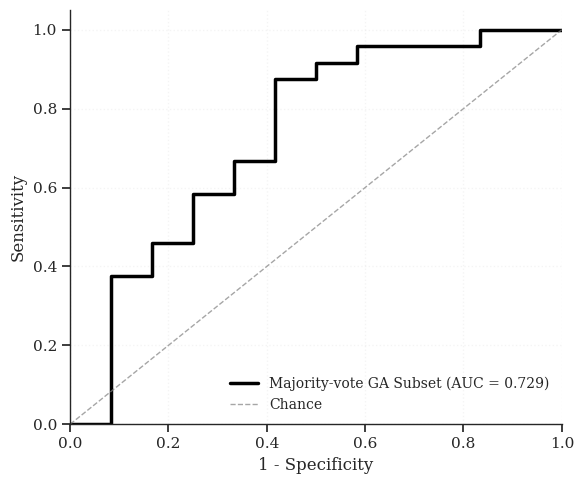

[INFO] 다수결 모델 결과가 저장되었습니다: MajorityVote\Figure_ROC_MajorityVote.png
Selected features (d=10): [ 6  9 12 16 21 22 24 25 26 29]


In [73]:
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# ---------------------------------------------------------
# 1. 저장 폴더 및 스타일 설정
# ---------------------------------------------------------
save_folder = "MajorityVote"
os.makedirs(save_folder, exist_ok=True)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.0

# ---------------------------------------------------------
# 0) Majority-vote feature subset 추출 (>= 3/5)
# ---------------------------------------------------------
ga5 = [fs for fs in feature_sets if fs["name"].startswith("GA-")]
if len(ga5) < 5:
    raise ValueError(f"Need 5 GA subsets. Found {len(ga5)}.")
ga5 = ga5[:5]

n_feat_total = X_train.shape[1]
cnt = np.zeros(n_feat_total, dtype=int)
for fs in ga5:
    cols = np.asarray(fs["cols"], dtype=int)
    cnt[cols] += 1

MAJ_K = 3
maj_cols = np.where(cnt >= MAJ_K)[0]

# 1) Tune RF (기존 함수 활용)
maj_label = f"GA-majority (k>={MAJ_K}/5)"
maj_best_params, maj_cv_best = tune_rf_for_features(maj_cols, maj_label)

# ---------------------------------------------------------
# 2. 모델 학습 및 테스트 데이터 평가
# ---------------------------------------------------------
Xtr = X_train.iloc[:, maj_cols].to_numpy()
ytr = y_np
Xte = X_test.iloc[:, maj_cols].to_numpy()
yte = y_te

final_clf = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_best_params
)
final_clf.fit(Xtr, ytr)

prob_te = final_clf.predict_proba(Xte)[:, 1]
test_auc = float(roc_auc_score(yte, prob_te))
fpr, tpr, _ = roc_curve(yte, prob_te)

# ---------------------------------------------------------
# 3. 논문용 클린 ROC 플롯 생성
# ---------------------------------------------------------
plt.figure(figsize=(6, 5))

# 메인 ROC 곡선 (검정색 굵은 선으로 강조)
plt.plot(
    fpr, tpr, 
    lw=2.5, 
    color="black", 
    label=f"Majority-vote GA Subset (AUC = {test_auc:.3f})"
)

# Chance line (점선)
plt.plot([0, 1], [0, 1], color='gray', lw=1.0, ls='--', alpha=0.7, label="Chance")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# 논문 규격 축 이름
plt.xlabel("1 - Specificity", fontsize=12)
plt.ylabel("Sensitivity", fontsize=12)

plt.legend(loc="lower right", fontsize=10, frameon=False)
plt.grid(alpha=0.2, ls=':')
sns.despine()

plt.tight_layout()

# ---------------------------------------------------------
# 4. 저장 (MajorityVote 폴더)
# ---------------------------------------------------------
save_path = os.path.join(save_folder, "Figure_ROC_MajorityVote.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] 다수결 모델 결과가 저장되었습니다: {save_path}")
print(f"Selected features (d={len(maj_cols)}): {maj_cols}")

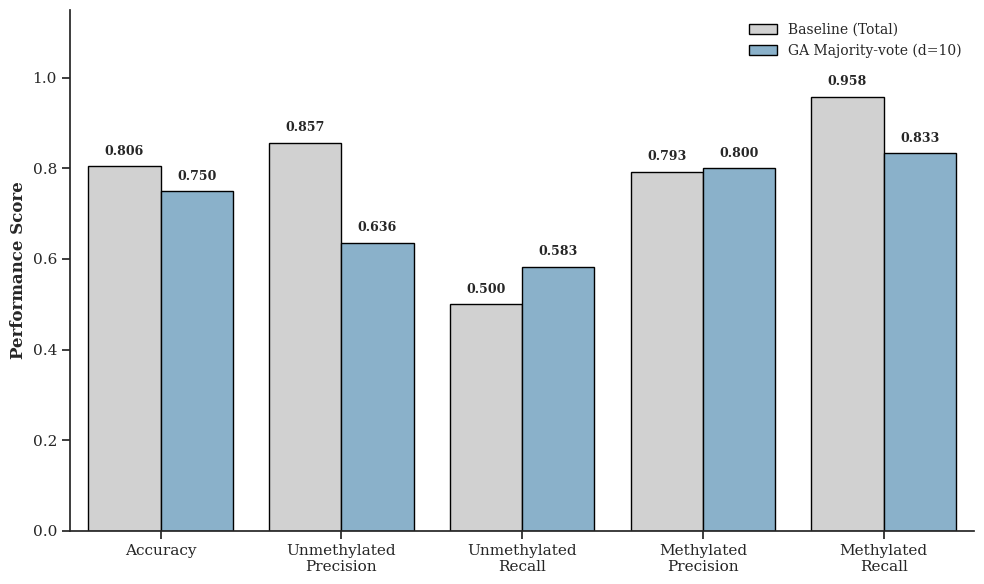

[INFO] 성능 지표 바 차트가 저장되었습니다: MajorityVote\Figure_Metrics_Comparison.png


In [74]:
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, accuracy_score

# ---------------------------------------------------------
# 1. 스타일 및 폴더 설정 (논문 규격)
# ---------------------------------------------------------
# Serif 폰트 적용 및 깔끔한 테두리 설정
sns.set_theme(style="ticks", rc={"font.family": "serif"})
save_folder = "MajorityVote"
os.makedirs(save_folder, exist_ok=True)

# ---------------------------------------------------------
# 2. 성능 데이터 계산 및 구조화
# ---------------------------------------------------------
# 앞서 학습된 final_clf (Maj-vote 모델)와 clf_base (Baseline) 사용
y_pred_ga_maj = final_clf.predict(Xte)

metrics_data = {
    'Metric': ['Accuracy', 'Unmethylated\nPrecision', 'Unmethylated\nRecall', 
               'Methylated\nPrecision', 'Methylated\nRecall'] * 2,
    'Score': [
        # RF (Baseline) - 앞선 셀에서 계산된 y_pred_baseline 사용
        accuracy_score(y_test, y_pred_baseline), 
        precision_score(y_test, y_pred_baseline, average=None)[0],
        recall_score(y_test, y_pred_baseline, average=None)[0],
        precision_score(y_test, y_pred_baseline, average=None)[1],
        recall_score(y_test, y_pred_baseline, average=None)[1],
        # RF (GA Maj-vote)
        accuracy_score(y_test, y_pred_ga_maj), 
        precision_score(y_test, y_pred_ga_maj, average=None)[0],
        recall_score(y_test, y_pred_ga_maj, average=None)[0],
        precision_score(y_test, y_pred_ga_maj, average=None)[1],
        recall_score(y_test, y_pred_ga_maj, average=None)[1]
    ],
    'Model': ['Baseline (Total)'] * 5 + [f'GA Majority-vote (d={len(maj_cols)})'] * 5
}

df_metrics = pd.DataFrame(metrics_data)

# ---------------------------------------------------------
# 3. 그래프 생성 (Clean Design)
# ---------------------------------------------------------


fig, ax = plt.subplots(figsize=(10, 6))
# 논문용 차분한 팔레트 사용 (회색 vs 하늘색)
sns.barplot(data=df_metrics, x='Metric', y='Score', hue='Model', 
            palette=['#d1d1d1', '#7fb3d5'], edgecolor='black', linewidth=1.0)

ax.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylim(0, 1.15) # 상단 라벨 공간 확보
sns.despine()

# 막대 위에 정확한 수치 표시 (소수점 3자리)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=6, weight='bold', size=9)

# 범례 설정 (테두리 제거)
plt.legend(frameon=False, loc='upper right', fontsize=10)
plt.tight_layout()

# ---------------------------------------------------------
# 4. 저장 (MajorityVote 폴더)
# ---------------------------------------------------------
save_path = os.path.join(save_folder, "Figure_Metrics_Comparison.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] 성능 지표 바 차트가 저장되었습니다: {save_path}")

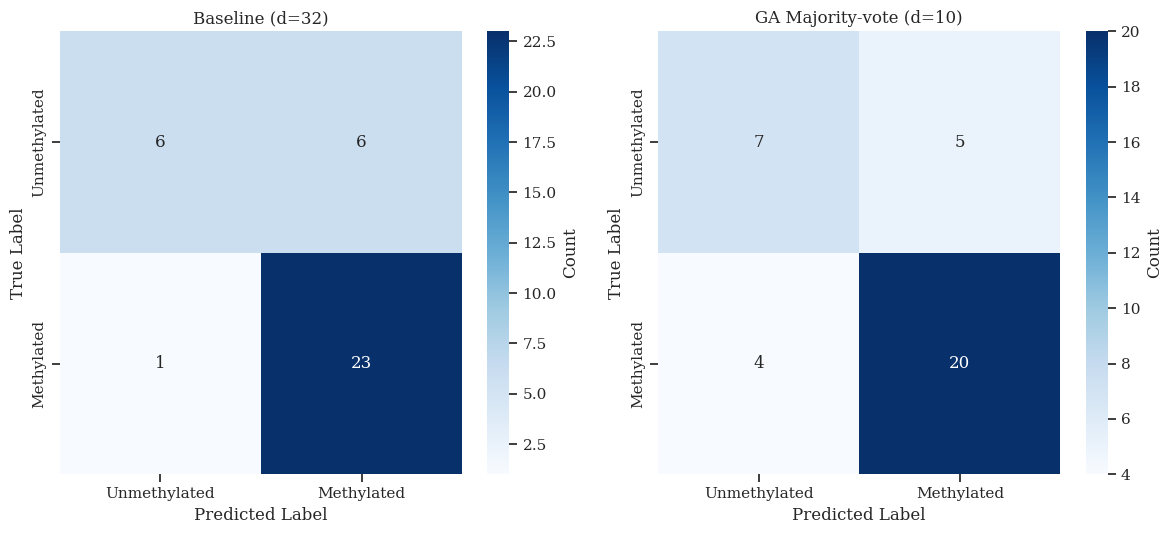

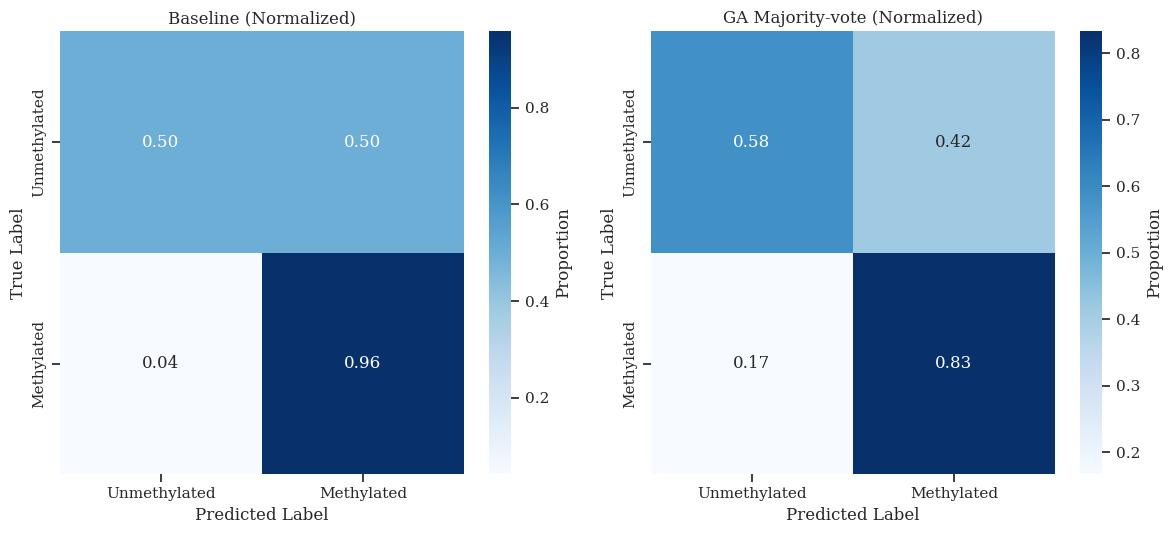

[INFO] 혼동 행렬 시각화 파일이 저장되었습니다: MajorityVote


In [75]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 1. 저장 폴더 및 스타일 설정
# ---------------------------------------------------------
save_folder = "MajorityVote"
os.makedirs(save_folder, exist_ok=True)

plt.rcParams['font.family'] = 'serif'
class_labels = ['Unmethylated', 'Methylated']

# ---------------------------------------------------------
# 2. Confusion Matrix 계산 (Maj-vote 예측값 사용)
# ---------------------------------------------------------
# 이전 셀에서 계산된 y_pred_baseline과 y_pred_ga_maj를 사용합니다.
cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=[0, 1])
cm_maj_vote = confusion_matrix(y_test, y_pred_ga_maj, labels=[0, 1])

# 정규화 (Proportion)
cm_base_norm = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]
cm_maj_norm  = cm_maj_vote.astype('float') / cm_maj_vote.sum(axis=1)[:, np.newaxis]

# ---------------------------------------------------------
# 3. Heatmap 시각화 및 저장 (Count & Normalized)
# ---------------------------------------------------------

# --- A: Count Confusion Matrix ---
fig_count, axes_count = plt.subplots(1, 2, figsize=(12, 5.5))

sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Count'}, ax=axes_count[0])
axes_count[0].set_title(f"Baseline (d={X_train.shape[1]})", fontsize=12)
axes_count[0].set_xlabel("Predicted Label")
axes_count[0].set_ylabel("True Label")

sns.heatmap(cm_maj_vote, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Count'}, ax=axes_count[1])
axes_count[1].set_title(f"GA Majority-vote (d={len(maj_cols)})", fontsize=12)
axes_count[1].set_xlabel("Predicted Label")
axes_count[1].set_ylabel("True Label")

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "Confusion_Matrix_Count.png"), dpi=300)

# --- B: Normalized Confusion Matrix ---
fig_norm, axes_norm = plt.subplots(1, 2, figsize=(12, 5.5))

sns.heatmap(cm_base_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Proportion'}, ax=axes_norm[0])
axes_norm[0].set_title("Baseline (Normalized)", fontsize=12)
axes_norm[0].set_xlabel("Predicted Label")
axes_norm[0].set_ylabel("True Label")

sns.heatmap(cm_maj_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_labels,
            yticklabels=class_labels, cbar_kws={'label': 'Proportion'}, ax=axes_norm[1])
axes_norm[1].set_title("GA Majority-vote (Normalized)", fontsize=12)
axes_norm[1].set_xlabel("Predicted Label")
axes_norm[1].set_ylabel("True Label")

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "Confusion_Matrix_Normalized.png"), dpi=300)
plt.show()

print(f"[INFO] 혼동 행렬 시각화 파일이 저장되었습니다: {save_folder}")

[INFO] Final Majority-vote RF model for SHAP trained. Features: 10


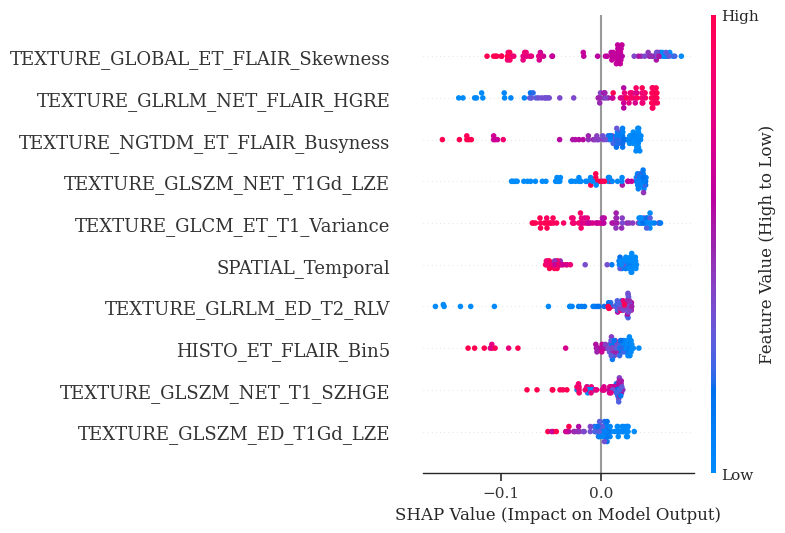

[INFO] SHAP Summary Plot이 저장되었습니다: MajorityVote\Figure_SHAP_MajorityVote.png


In [76]:
import os
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------
# 1. 저장 폴더 및 스타일 설정
# ---------------------------------------------------------
save_folder = "MajorityVote"
os.makedirs(save_folder, exist_ok=True)

# 논문용 폰트 설정
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.linewidth'] = 1.0

# ---------------------------------------------------------
# 2. 모델 학습 (Majority-vote Subset)
# ---------------------------------------------------------
# 앞서 선택된 maj_cols와 maj_best_params 사용
Xtr_maj = X_train.iloc[:, maj_cols]
y_tr    = y_train.to_numpy().ravel()

rf_maj_shap = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_best_params
)
rf_maj_shap.fit(Xtr_maj, y_tr)

print(f"[INFO] Final Majority-vote RF model for SHAP trained. Features: {Xtr_maj.shape[1]}")

# ---------------------------------------------------------
# 3. SHAP 계산 (TreeExplainer)
# ---------------------------------------------------------
explainer = shap.TreeExplainer(rf_maj_shap)
shap_values = explainer.shap_values(Xtr_maj)

# 이진 분류 데이터 구조 처리
# scikit-learn RF 결과가 리스트인 경우 Positive(1) 클래스 선택
if isinstance(shap_values, list):
    vals_to_plot = shap_values[1]
else:
    vals_to_plot = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

# ---------------------------------------------------------
# 4. 시각화 및 고해상도 저장
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))



# SHAP Summary Plot 생성 (불필요한 제목 제거)
shap.summary_plot(
    vals_to_plot, 
    Xtr_maj, 
    feature_names=Xtr_maj.columns,
    max_display=15,
    plot_type="dot", 
    show=False
)

# 축 라벨 정돈
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
plt.gcf().axes[-1].set_ylabel("Feature Value (High to Low)", fontsize=12)

# 여백 조정 및 파일 저장
plt.tight_layout()
save_path = os.path.join(save_folder, "Figure_SHAP_MajorityVote.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] SHAP Summary Plot이 저장되었습니다: {save_path}")

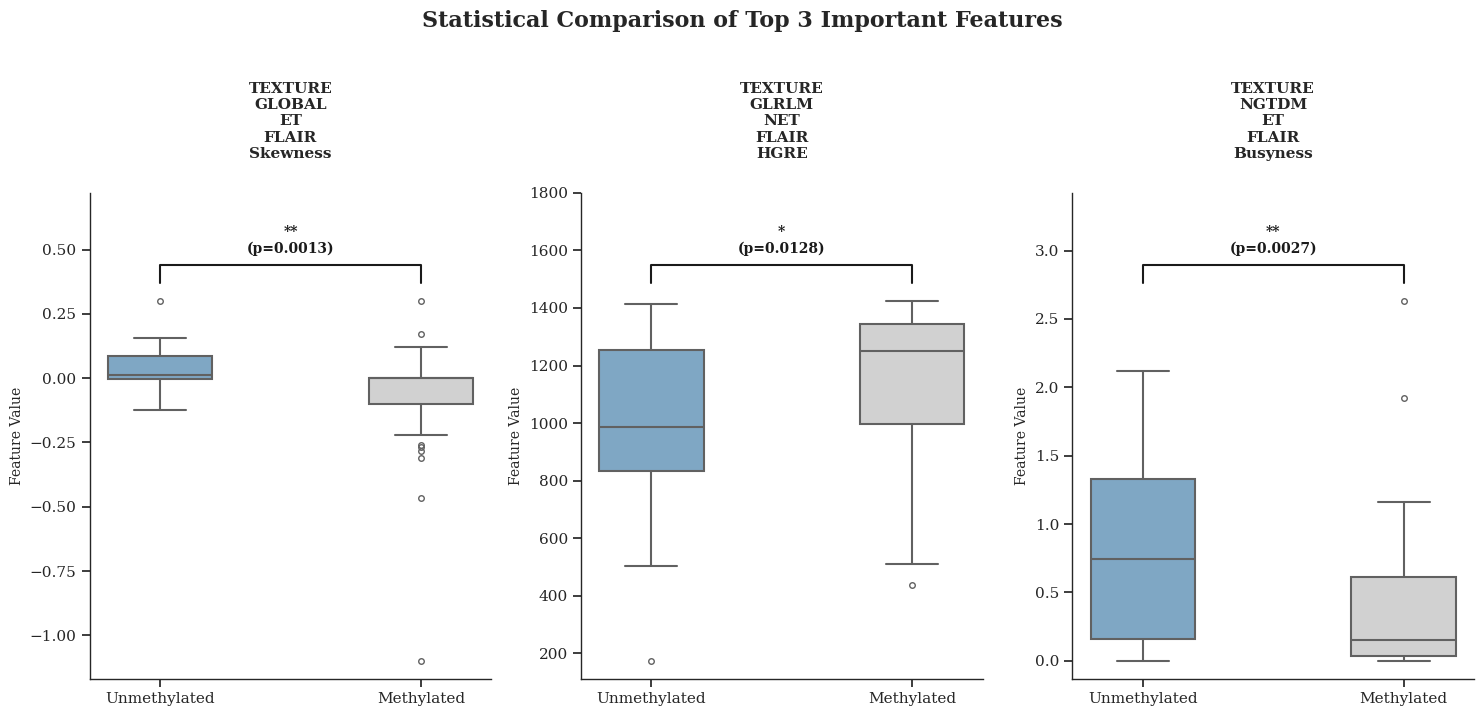

[INFO] 사용자님 스타일의 Box Plot이 저장되었습니다: MajorityVote\Figure_Top3_BoxPlots_MajorityVote.png


In [77]:
# ---------------------------------------------------------
# 1. SHAP 기반 Top 3 피처 추출 (AttributeError 방지형)
# ---------------------------------------------------------
shap_importance = np.abs(vals_to_plot).mean(axis=0)
top3_indices = np.argsort(shap_importance)[::-1][:3]

# [수정] Xtr_ga 대신 현재 사용 중인 Xtr_maj와 원본 컬럼명 사용
all_maj_feature_names = X_train.columns[maj_cols] 
top3_features = all_maj_feature_names[top3_indices]

# ---------------------------------------------------------
# 2. 데이터 준비 (Numpy 대응)
# ---------------------------------------------------------
# [수정] Xtr_maj를 안전하게 DataFrame으로 변환 후 추출
df_top3 = pd.DataFrame(Xtr_maj, columns=all_maj_feature_names)[top3_features].copy()
class_labels_dict = {0: 'Unmethylated', 1: 'Methylated'}
df_top3['Class'] = [class_labels_dict[val] for val in y_tr]

# ---------------------------------------------------------
# 3. 시각화 (사용자님의 15x7 사이즈 및 스타일 그대로)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 7)) # 사용자님 원본 사이즈
my_palette = {'Unmethylated': '#74a9cf', 'Methylated': '#d1d1d1'}
order = ['Unmethylated', 'Methylated']

for i, feature in enumerate(top3_features):
    # Box Plot (사용자님 설정: fliersize=4, linewidth=1.5)
    sns.boxplot(
        data=df_top3, x='Class', y=feature, hue='Class', legend=False,
        ax=axes[i], palette=my_palette, width=0.4, fliersize=4,
        linewidth=1.5, order=order
    )
    
    # --- Statistical Test (Mann-Whitney U) ---
    group1 = df_top3[df_top3['Class'] == 'Unmethylated'][feature]
    group2 = df_top3[df_top3['Class'] == 'Methylated'][feature]
    stat, p_val = mannwhitneyu(group1, group2, alternative='two-sided')

    # 유의성 별표 처리
    if p_val < 0.001: sig = "***"
    elif p_val < 0.01: sig = "**"
    elif p_val < 0.05: sig = "*"
    else: sig = "n.s."

    # Annotation logic (사용자님 원본 수치: 2*h, 2.5*h)
    y_max = df_top3[feature].max()
    y_min = df_top3[feature].min()
    h = (y_max - y_min) * 0.05
    
    # 브라켓과 텍스트
    axes[i].plot([0, 0, 1, 1], [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h], lw=1.5, c='k')
    axes[i].text(0.5, y_max + 2.5*h, f"{sig}\n(p={p_val:.4f})", 
                 ha='center', va='bottom', color='k', fontsize=10, fontweight='bold')

    # 스타일링 (사용자님 원본 설정)
    display_title = feature.replace('_', '\n')
    axes[i].set_title(display_title, fontsize=11, fontweight='bold', pad=25)
    axes[i].set_ylabel("Feature Value", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylim(y_min - h, y_max + 6*h) 
    sns.despine(ax=axes[i])

plt.suptitle("Statistical Comparison of Top 3 Important Features", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# 저장
save_path_stat = os.path.join(save_folder, "Figure_Top3_BoxPlots_MajorityVote.png")
plt.savefig(save_path_stat, dpi=300, bbox_inches='tight')
plt.show()

print(f"[INFO] 사용자님 스타일의 Box Plot이 저장되었습니다: {save_path_stat}")

In [78]:
# Get the feature names for the majority-vote subset
maj_feature_names = X_train.columns[maj_cols]

print(f"\n[INFO] SHAP features used (total={len(maj_feature_names)}):")
for i, name in enumerate(maj_feature_names, 1):
    print(f"{i:02d}. {name}")

# (Optional) Print as a single Python list for easy copy/paste
print("\n[INFO] Feature list:")
print(list(maj_feature_names))



[INFO] SHAP features used (total=10):
01. HISTO_ET_FLAIR_Bin5
02. SPATIAL_Temporal
03. TEXTURE_GLOBAL_ET_FLAIR_Skewness
04. TEXTURE_GLCM_ET_T1_Variance
05. TEXTURE_GLRLM_ED_T2_RLV
06. TEXTURE_GLRLM_NET_FLAIR_HGRE
07. TEXTURE_GLSZM_ED_T1Gd_LZE
08. TEXTURE_GLSZM_NET_T1Gd_LZE
09. TEXTURE_GLSZM_NET_T1_SZHGE
10. TEXTURE_NGTDM_ET_FLAIR_Busyness

[INFO] Feature list:
['HISTO_ET_FLAIR_Bin5', 'SPATIAL_Temporal', 'TEXTURE_GLOBAL_ET_FLAIR_Skewness', 'TEXTURE_GLCM_ET_T1_Variance', 'TEXTURE_GLRLM_ED_T2_RLV', 'TEXTURE_GLRLM_NET_FLAIR_HGRE', 'TEXTURE_GLSZM_ED_T1Gd_LZE', 'TEXTURE_GLSZM_NET_T1Gd_LZE', 'TEXTURE_GLSZM_NET_T1_SZHGE', 'TEXTURE_NGTDM_ET_FLAIR_Busyness']


Permutation importance identified a small set of features whose permutation caused the largest drop in training ROC AUC, suggesting these features contribute most strongly to the model’s predictive performance.


===== Permutation Importance (TRAIN, ROC AUC drop) =====


,feature,perm_importance_mean,perm_importance_std
5,TEXTURE_GLRLM_NET_FLAIR_HGRE,0.036574,0.011179
2,TEXTURE_GLOBAL_ET_FLAIR_Skewness,0.013591,0.009880
4,TEXTURE_GLRLM_ED_T2_RLV,0.010417,0.007509
9,TEXTURE_NGTDM_ET_FLAIR_Busyness,0.008102,0.009102
0,HISTO_ET_FLAIR_Bin5,0.006812,0.009344
6,TEXTURE_GLSZM_ED_T1Gd_LZE,0.006779,0.003226
7,TEXTURE_GLSZM_NET_T1Gd_LZE,0.006217,0.004995
8,TEXTURE_GLSZM_NET_T1_SZHGE,0.003042,0.003661
1,SPATIAL_Temporal,0.002315,0.006049
3,TEXTURE_GLCM_ET_T1_Variance,0.000198,0.005204


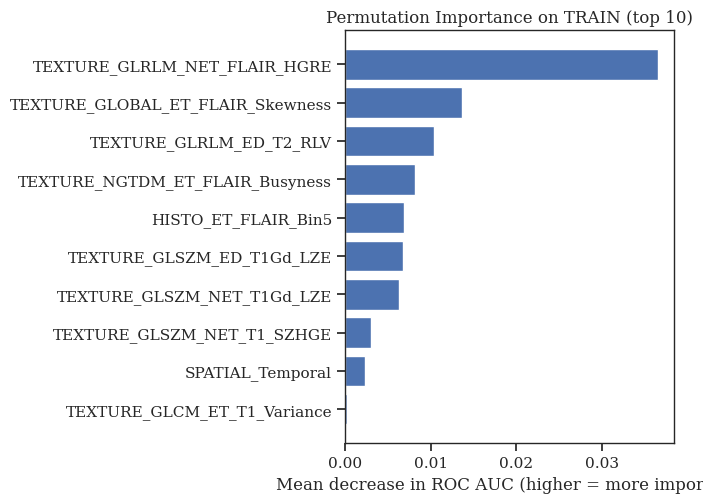

In [79]:
# Cell: Permutation Importance on TRAIN (ROC AUC drop) — use for interpretation

from sklearn.inspection import permutation_importance

# 0) Train final RF on FULL TRAIN (same params as evaluation)
Xtr_maj = X_train.iloc[:, maj_cols].to_numpy()
ytr     = y_np

rf = RandomForestClassifier(
    random_state=2042,
    n_jobs=-1,
    **maj_best_params
)
rf.fit(Xtr_maj, ytr)

feat_names = X_train.columns[maj_cols]

# 1) Permutation importance on TRAIN (AUC drop)
perm = permutation_importance(
    rf,
    Xtr_maj, ytr,
    scoring="roc_auc",
    n_repeats=20,
    random_state=2042,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": feat_names,
    "perm_importance_mean": perm.importances_mean,
    "perm_importance_std":  perm.importances_std,
}).sort_values("perm_importance_mean", ascending=False)

print("\n===== Permutation Importance (TRAIN, ROC AUC drop) =====")
display(imp_df.head(15))

topk = 10
plot_df = imp_df.head(topk).iloc[::-1]
plt.figure(figsize=(7.0, 5.2))
plt.barh(plot_df["feature"], plot_df["perm_importance_mean"])
plt.xlabel("Mean decrease in ROC AUC (higher = more important)")
plt.title(f"Permutation Importance on TRAIN (top {topk})")
plt.tight_layout()
plt.show()


In [80]:
# Cell: Report baseline TRAIN/TEST AUC + show AUC after permuting top features (TRAIN + TEST)

rng = np.random.default_rng(2042)

# 0) Baseline AUC on TRAIN and TEST (using the same trained rf)
prob_tr = rf.predict_proba(Xtr_maj)[:, 1]
train_auc = float(roc_auc_score(ytr, prob_tr))

Xte_maj = X_test.iloc[:, maj_cols].to_numpy()
prob_te = rf.predict_proba(Xte_maj)[:, 1]
test_auc = float(roc_auc_score(y_te, prob_te))

print("\n===== Baseline performance (same fitted model) =====")
print(f"TRAIN AUC: {train_auc:.4f}")
print(f"TEST  AUC: {test_auc:.4f}")

# 1) AUC after permuting each top feature once (single run) on TRAIN and TEST
TOPM = 5
top_features = imp_df["feature"].head(TOPM).tolist()
name_to_j = {name: j for j, name in enumerate(feat_names)}

print(f"\n===== AUC after permuting top {TOPM} features on TRAIN (single shuffle each) =====")
for name in top_features:
    j = name_to_j[name]

    Xtr_perm = Xtr_maj.copy()
    Xtr_perm[:, j] = np.random.permutation(Xtr_perm[:, j])

    prob_perm = rf.predict_proba(Xtr_perm)[:, 1]
    auc_perm  = float(roc_auc_score(ytr, prob_perm))

    print(f"{name}: TRAIN AUC {auc_perm:.4f}  (drop {train_auc - auc_perm:+.4f})")

print(f"\n===== AUC after permuting top {TOPM} features on TEST (single shuffle each) =====")
for name in top_features:
    j = name_to_j[name]

    Xte_perm = Xte_maj.copy()
    Xte_perm[:, j] = np.random.permutation(Xte_perm[:, j])

    prob_perm = rf.predict_proba(Xte_perm)[:, 1]
    auc_perm  = float(roc_auc_score(y_te, prob_perm))

    print(f"{name}: TEST  AUC {auc_perm:.4f}  (drop {test_auc - auc_perm:+.4f})")



===== Baseline performance (same fitted model) =====
TRAIN AUC: 0.9676
TEST  AUC: 0.7292

===== AUC after permuting top 5 features on TRAIN (single shuffle each) =====
TEXTURE_GLRLM_NET_FLAIR_HGRE: TRAIN AUC 0.9444  (drop +0.0231)


TEXTURE_GLOBAL_ET_FLAIR_Skewness: TRAIN AUC 0.9491  (drop +0.0185)
TEXTURE_GLRLM_ED_T2_RLV: TRAIN AUC 0.9550  (drop +0.0126)
TEXTURE_NGTDM_ET_FLAIR_Busyness: TRAIN AUC 0.9722  (drop -0.0046)
HISTO_ET_FLAIR_Bin5: TRAIN AUC 0.9597  (drop +0.0079)

===== AUC after permuting top 5 features on TEST (single shuffle each) =====
TEXTURE_GLRLM_NET_FLAIR_HGRE: TEST  AUC 0.6944  (drop +0.0347)
TEXTURE_GLOBAL_ET_FLAIR_Skewness: TEST  AUC 0.7222  (drop +0.0069)
TEXTURE_GLRLM_ED_T2_RLV: TEST  AUC 0.6424  (drop +0.0868)
TEXTURE_NGTDM_ET_FLAIR_Busyness: TEST  AUC 0.7535  (drop -0.0243)
HISTO_ET_FLAIR_Bin5: TEST  AUC 0.7118  (drop +0.0174)
